In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from Training_model import train_model
from Data_generation import make_loader
from OneHot_model import OneHotDecoder
from Model_analysis import (
    statistical_complexity,
    statistical_complexity_empirical,
    statistical_complexity_compare,
    FW_BW_attention_comparison,
    FW_BW_loss_comparison,
    compare_FW_BW_latents,
    plot_attention_heatmap,
    plot_perplexity,
    compare_FW_BW_latents, latent_extraction
)

/Users/tisornnaphattalung/Desktop/Quantum/URECA/URECA_qt_llm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Check New code

In [3]:
import umap
def draw_umap(data, color=None, n_neighbors=300, min_dist=0.1, n_components=2, metric='euclidean', title=''):
    fit = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, n_components=n_components, metric=metric)
    u = fit.fit_transform(data)

    fig = plt.figure()
    ax = fig.add_subplot(111) if n_components != 3 else fig.add_subplot(111, projection='3d')

    if color is None:
        color = np.arange(len(data))  # default: timestep coloring

    if n_components == 2:
        sc = ax.scatter(u[:,0], u[:,1], c=color, s=10, cmap='plasma')
        plt.colorbar(sc)
    elif n_components == 3:
        sc = ax.scatter(u[:,0], u[:,1], u[:,2], c=color, s=10, cmap='plasma')
        plt.colorbar(sc)

    plt.title(title, fontsize=18)
    plt.show()

In [50]:
num_token = 3
d_model = 20
max_len = 500
batch_size = 32
num_samples = batch_size*10
max_epochs = 20
lr = 1e-2
p, q = 0.4, 0.8

train_loader = make_loader(pp = p, qq = q, batch_size = batch_size, seq_len = max_len, 
                               num_samples = num_samples, mode = "forward")
train_loader_bw = make_loader(pp = p, qq = q, batch_size = batch_size, seq_len = max_len, 
                               num_samples = num_samples, mode = "backward")


records_fw = train_model(train_loader, num_token, d_model, max_len, max_epochs, lr=lr,
                         mode = 'forward', embed_type="onehot")
records_bw = train_model(train_loader_bw, num_token, d_model, max_len, max_epochs, lr=lr,
                         mode = 'forward', embed_type="onehot")

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name         | Type               | Params | Mode  | FLOPs
--------------------------------------------------------------------
0 | we           | Embedding          | 60     | train | 0    
1 | pe           | PositionalEncoding | 0      | train | 0    
2 | attn_layers  | ModuleList         | 2.5 K  | train | 0    
3 | ffn_layers   | ModuleList         | 6.6 K  | train | 0    
4 | ln_attn      | ModuleList         | 80     | train | 0    
5 | ln_ffn       | ModuleList         | 80     | train | 0    
6 | output_prj   | Linear             | 63     | train | 0    
  | other params | n/a                | 60     | n/a   | n/a  
--------------------------------------------------------------------
9.5 K     

Epoch 19: 100%|██████████| 10/10 [00:00<00:00, 39.26it/s, v_num=1913, train_loss_step=0.895, train_perplexity_step=2.450, train_loss_epoch=0.890, train_perplexity_epoch=2.440]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 10/10 [00:00<00:00, 33.71it/s, v_num=1913, train_loss_step=0.895, train_perplexity_step=2.450, train_loss_epoch=0.890, train_perplexity_epoch=2.440]


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name         | Type               | Params | Mode  | FLOPs
--------------------------------------------------------------------
0 | we           | Embedding          | 60     | train | 0    
1 | pe           | PositionalEncoding | 0      | train | 0    
2 | attn_layers  | ModuleList         | 2.5 K  | train | 0    
3 | ffn_layers   | ModuleList         | 6.6 K  | train | 0    
4 | ln_attn      | ModuleList         | 80     | train | 0    
5 | ln_ffn       | ModuleList         | 80     | train | 0    
6 | output_prj   | Linear             | 63     | train | 0    
  | other params | n/a                | 60     | n/a   | n/a  
--------------------------------------------------------------------
9.5 K     

Epoch 19: 100%|██████████| 10/10 [00:00<00:00, 44.90it/s, v_num=1914, train_loss_step=0.884, train_perplexity_step=2.420, train_loss_epoch=0.889, train_perplexity_epoch=2.430]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 10/10 [00:00<00:00, 41.12it/s, v_num=1914, train_loss_step=0.884, train_perplexity_step=2.420, train_loss_epoch=0.889, train_perplexity_epoch=2.430]


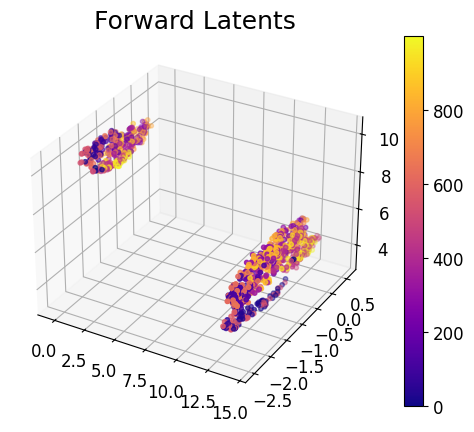

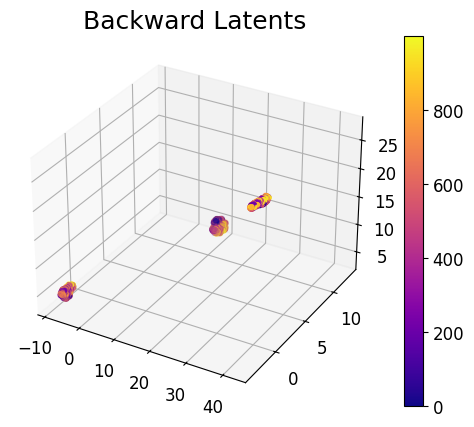

In [15]:
n = 1000
latents_fw,_,_ = latent_extraction(records_fw.model, train_loader)
latents_bw,_,_ = latent_extraction(records_bw.model, train_loader)

flat_latents_fw = latents_fw.reshape(-1, latents_fw.shape[-1])
reduced = flat_latents_fw[:n]
draw_umap(reduced, color=None, n_neighbors=100, min_dist=0.1, n_components=3, metric='euclidean', title='Forward Latents')

flat_latents_bw = latents_bw.reshape(-1, latents_bw.shape[-1])
reduced = flat_latents_bw[:n]
draw_umap(reduced, color=None, n_neighbors=100, min_dist=0.1, n_components=3, metric='euclidean', title='Backward Latents')

In [46]:
statistical_complexity(p, q, mode = "forward")

np.float64(0.9182958340516041)

In [17]:
statistical_complexity_empirical(records_fw.model, train_loader_bw, use_t="first", k=2)

np.float64(0.8995602017263886)

In [10]:
# Print what the backward loader actually gives
for batch in train_loader:
    inputs, targets = batch  # BEFORE any swap
    print("Batch[0] input:", inputs[0, :10])
    print("Batch[0] target:", targets[0, :10])
    break

Batch[0] input: tensor([1, 2, 0, 1, 2, 0, 0, 1, 2, 0])
Batch[0] target: tensor([2, 0, 1, 2, 0, 0, 1, 2, 0, 0])


Text(0, 0.5, 'Loss Difference')

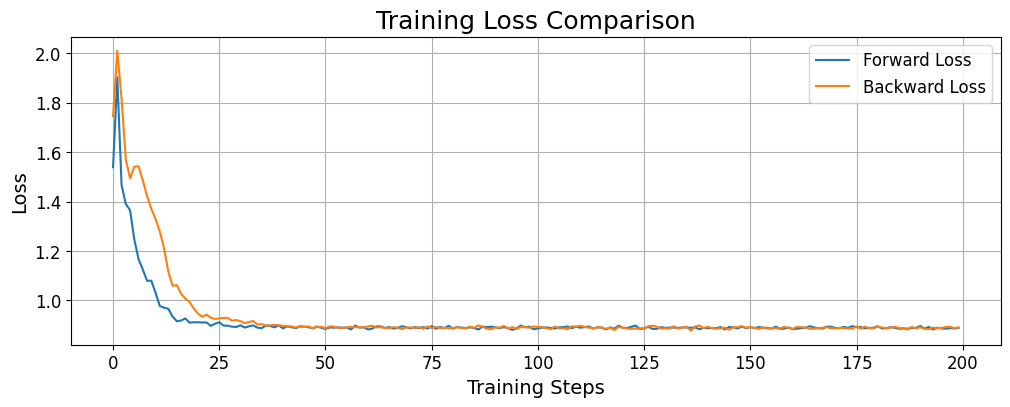

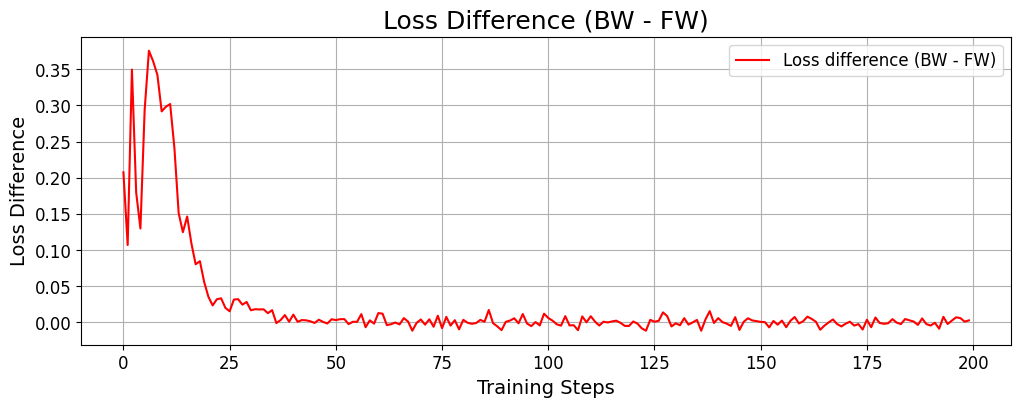

In [18]:
plt.figure(figsize=(12,4))
plt.plot(records_fw.step_loss, label='Forward Loss')
plt.plot(records_bw.step_loss, label='Backward Loss')
plt.legend()
plt.grid()
plt.title('Training Loss Comparison', fontsize=18)
plt.xlabel('Training Steps')
plt.ylabel('Loss')

plt.figure(figsize=(12,4))
plt.plot(np.array(records_bw.step_loss) - np.array(records_fw.step_loss), label='Loss difference (BW - FW)', color = 'red')
plt.legend()
plt.grid()
plt.title('Loss Difference (BW - FW)', fontsize=18)
plt.xlabel('Training Steps')
plt.ylabel('Loss Difference')

In [51]:
records_fw.epoch_loss[-1], records_bw.epoch_loss[-1], records_bw.epoch_loss[-1] - records_fw.epoch_loss[-1]

(0.8885767102241516, 0.887133777141571, -0.0014429330825805886)

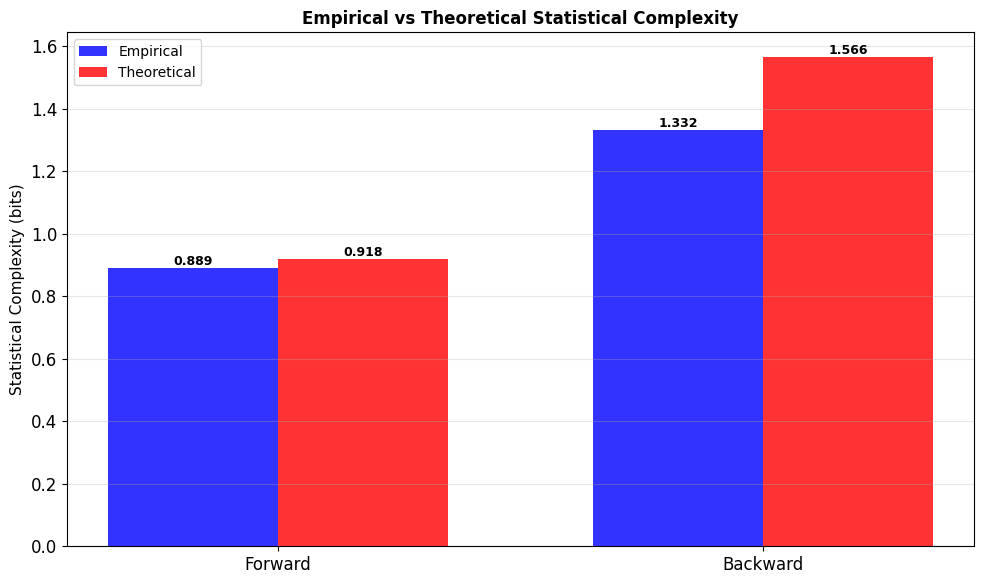

In [2]:
from Data_generation import HMM_generation
HMM_generation(num_samples = 5, seq_len = 5, p = 0.4, q = 0.8)

([[2, 0, 1, 2, 1, 1, 1, 2, 0, 1, 2, 1, 2, 1, 1],
  [1, 2, 0, 0, 1, 2, 1, 2, 0, 0, 1, 2, 0, 0, 1],
  [0, 1, 1, 2, 1, 2, 1, 2, 1, 2, 0, 0, 0, 0, 1],
  [2, 0, 0, 1, 2, 0, 0, 1, 2, 0, 0, 0, 0, 1, 2],
  [2, 1, 2, 0, 1, 1, 2, 0, 0, 0, 1, 2, 1, 2, 1]],
 [[0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1],
  [1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1],
  [0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1],
  [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
  [0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1]])

In [3]:
from Data_generation import Rev_HMM_generation
Rev_HMM_generation(num_samples = 5, seq_len = 5, p = 0.4, q = 0.8)

([[1, 0, 0, 0, 0, 2, 1, 1, 1, 2, 1, 0, 0, 2, 1],
  [0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 0, 2, 1, 0, 2],
  [1, 2, 1, 1, 2, 1, 2, 1, 1, 0, 0, 0, 0, 2, 1],
  [0, 2, 1, 2, 1, 0, 0, 0, 0, 2, 1, 0, 0, 0, 0],
  [2, 1, 0, 2, 1, 0, 0, 0, 0, 2, 1, 2, 1, 0, 2]],
 [[1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1],
  [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0],
  [1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1],
  [0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
  [0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0]])

# Testing Reverse input in forward model:

- compare:
Reverse input in forward model = forward input in backward model

(sanity check)

In [26]:
num_token = 3
d_model = 20
max_len = 800
batch_size = 32
num_samples = batch_size*10
max_epochs = 50
lr = 1e-2
p, q = 0.4, 0.8

rev_train_loader = make_loader(pp = p, qq = q, batch_size = batch_size, seq_len = max_len, 
                               num_samples = num_samples, mode = "backward")
train_loader = make_loader(pp = p, qq = q, batch_size = batch_size, seq_len = max_len, 
                               num_samples = num_samples, mode = "forward")


records_fw_data_fw_model = train_model(train_loader, num_token, d_model, max_len, max_epochs, lr=lr,
                         mode = 'forward', embed_type="onehot")
records_rev_data_fw_model = train_model(rev_train_loader, num_token, d_model, max_len, max_epochs, lr=lr,
                         mode = 'forward', embed_type="onehot")
records_fw_data_rev_model = train_model(train_loader, num_token, d_model, max_len, max_epochs, lr=lr,
                         mode = 'backward', embed_type="onehot")
records_rev_data_rev_model = train_model(rev_train_loader, num_token, d_model, max_len, max_epochs, lr=lr,
                         mode = 'backward', embed_type="onehot")
# records_fw_data_fw_model = records_rev_data_rev_model
# records_rev_data_fw_model = records_rev_data_rev_model

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name         | Type               | Params | Mode  | FLOPs
--------------------------------------------------------------------
0 | we           | Embedding          | 60     | train | 0    
1 | pe           | PositionalEncoding | 0      | train | 0    
2 | attn_layers  | ModuleList         | 2.5 K  | train | 0    
3 | ffn_layers   | ModuleList         | 6.6 K  | train | 0    
4 | ln_attn      | ModuleList         | 80     | train | 0    
5 | ln_ffn       | ModuleList         | 80     | train | 0    
6 | output_prj   | Linear             | 63     | train | 0    
  | other params | n/a                | 60     | n/a   | n/a  
--------------------------------------------------------------------
9.5 K     

Epoch 49: 100%|██████████| 10/10 [00:00<00:00, 21.93it/s, v_num=1868, train_loss_step=0.888, train_perplexity_step=2.430, train_loss_epoch=0.885, train_perplexity_epoch=2.420]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 10/10 [00:00<00:00, 21.03it/s, v_num=1868, train_loss_step=0.888, train_perplexity_step=2.430, train_loss_epoch=0.885, train_perplexity_epoch=2.420]

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


...

Epoch 49: 100%|██████████| 10/10 [00:00<00:00, 22.44it/s, v_num=1870, train_loss_step=0.885, train_perplexity_step=2.420, train_loss_epoch=0.885, train_perplexity_epoch=2.420]


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name         | Type               | Params | Mode  | FLOPs
--------------------------------------------------------------------
0 | we           | Embedding          | 60     | train | 0    
1 | pe           | PositionalEncoding | 0      | train | 0    
2 | attn_layers  | ModuleList         | 2.5 K  | train | 0    
3 | ffn_layers   | ModuleList         | 6.6 K  | train | 0    
4 | ln_attn      | ModuleList         | 80     | train | 0    
5 | ln_ffn       | ModuleList         | 80     | train | 0    
6 | output_prj   | Linear             | 63     | train | 0    
  | other params | n/a                | 60     | n/a   | n/a  
--------------------------------------------------------------------
9.5 K     

Epoch 49: 100%|██████████| 10/10 [00:00<00:00, 17.76it/s, v_num=1871, train_loss_step=0.886, train_perplexity_step=2.430, train_loss_epoch=0.889, train_perplexity_epoch=2.430]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 10/10 [00:00<00:00, 17.11it/s, v_num=1871, train_loss_step=0.886, train_perplexity_step=2.430, train_loss_epoch=0.889, train_perplexity_epoch=2.430]


Prelim

In [53]:
input, target = next(iter(train_loader))

In [55]:
input, target

(tensor([[1, 2, 1,  ..., 1, 2, 1],
         [1, 1, 2,  ..., 1, 2, 1],
         [0, 1, 2,  ..., 0, 1, 1],
         ...,
         [2, 1, 2,  ..., 2, 0, 1],
         [2, 1, 2,  ..., 0, 0, 1],
         [2, 0, 1,  ..., 0, 0, 1]]),
 tensor([[2, 1, 2,  ..., 2, 1, 1],
         [1, 2, 0,  ..., 2, 1, 1],
         [1, 2, 1,  ..., 1, 1, 2],
         ...,
         [1, 2, 1,  ..., 0, 1, 2],
         [1, 2, 1,  ..., 0, 1, 2],
         [0, 1, 2,  ..., 0, 1, 2]]))

In [27]:
model_fw_data_fw_model = records_fw_data_fw_model.model
model_bw_data_fw_model = records_rev_data_fw_model.model
model_fw_data_bw_model = records_fw_data_rev_model.model
model_bw_data_bw_model = records_rev_data_rev_model.model

latents_fw_data_fw_model, input_fw_data_fw_model, _ = latent_extraction(model_fw_data_fw_model, train_loader)
latents_bw_data_fw_model, input_bw_data_fw_model, _ = latent_extraction(model_bw_data_fw_model, rev_train_loader)
latents_fw_data_bw_model, input_fw_data_bw_model, _ = latent_extraction(model_fw_data_bw_model, train_loader)
latents_bw_data_bw_model, input_bw_data_bw_model, _ = latent_extraction(model_bw_data_bw_model, rev_train_loader)

In [23]:
latents_fw_data_bw_model

array([[[ 2.0697231 ,  2.8299897 , -1.9170145 , ..., -1.7328422 ,
         -3.0295942 ,  1.8260198 ],
        [ 2.0022922 ,  0.98499095,  0.35091323, ..., -0.45226854,
         -1.4082452 ,  1.0086423 ],
        [ 0.19568191, -3.1936622 ,  3.6272917 , ...,  2.535986  ,
          1.4460565 , -2.1194675 ],
        ...,
        [ 1.9533645 ,  0.2040675 ,  0.67710954, ..., -0.8083061 ,
         -1.5045096 ,  0.46556118],
        [ 0.13065124, -2.7646534 ,  2.9923744 , ...,  2.1322937 ,
          0.7693754 , -2.0500617 ],
        [ 0.5046898 , -1.0380002 ,  1.5615907 , ..., -1.0404942 ,
         -1.4224161 ,  0.60799325]],

       [[ 1.2616937 ,  1.4230969 ,  0.01499195, ..., -0.5205997 ,
         -1.3918645 ,  1.0430887 ],
        [ 0.24047947, -2.4052124 ,  3.4584913 , ...,  2.5728931 ,
          1.7431215 , -2.1711125 ],
        [ 2.9197073 ,  1.5135639 , -1.2709322 , ..., -1.7169158 ,
         -3.2690513 ,  1.8869748 ],
        ...,
        [ 1.9533645 ,  0.2040675 ,  0.67710954, ..., -

In [28]:
n = 1000

flat_latents_fw_data_fw_model = latents_fw_data_fw_model.reshape(-1, latents_fw_data_fw_model.shape[-1])
reduced_fw_data_fw_model = flat_latents_fw_data_fw_model[:n]
reduced_int_fw_data_fw_model = input_fw_data_fw_model.reshape(-1)[:n]

flat_latents_bw_data_fw_model = latents_bw_data_fw_model.reshape(-1, latents_bw_data_fw_model.shape[-1])
reduced_bw_data_fw_model = flat_latents_bw_data_fw_model[:n]
reduced_int_bw_data_fw_model = input_bw_data_fw_model.reshape(-1)[:n]


flat_latents_fw_data_bw_model = latents_fw_data_bw_model.reshape(-1, latents_fw_data_bw_model.shape[-1])
reduced_fw_data_bw_model = flat_latents_fw_data_bw_model[:n]
reduced_int_fw_data_bw_model = input_fw_data_bw_model.reshape(-1)[:n]

flat_latents_bw_data_bw_model = latents_bw_data_bw_model.reshape(-1, latents_bw_data_bw_model.shape[-1])
reduced_bw_data_bw_model = flat_latents_bw_data_bw_model[:n]
reduced_int_bw_data_bw_model = input_bw_data_bw_model.reshape(-1)[:n]

In [29]:
reduced_fw_data_bw_model

array([[-4.0772843 ,  3.3995142 ,  2.2927263 , ..., -0.12269364,
         2.3262303 ,  2.248385  ],
       [ 0.04450344,  0.6741148 ,  0.57282066, ..., -0.4648295 ,
         1.1348486 ,  0.8959435 ],
       [ 0.28342637, -0.2507751 ,  0.47651267, ..., -0.01472473,
         0.45385492,  0.83418584],
       ...,
       [-2.966944  ,  3.7413707 ,  2.561667  , ...,  1.1479005 ,
         1.0571328 ,  2.6739135 ],
       [ 0.34727558,  1.3982656 ,  0.17638066, ...,  0.20515749,
         0.43575957,  1.3615402 ],
       [ 6.2556057 , -4.6468587 , -3.4488363 , ..., -1.2756932 ,
        -2.416318  , -4.9632955 ]], shape=(1000, 20), dtype=float32)

In [6]:
import umap
def draw_umap(data, color=None, n_neighbors=300, min_dist=0.1, n_components=2, metric='euclidean', title=''):
    fit = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, n_components=n_components, metric=metric)
    u = fit.fit_transform(data)

    fig = plt.figure()
    ax = fig.add_subplot(111) if n_components != 3 else fig.add_subplot(111, projection='3d')

    if color is None:
        color = np.arange(len(data))  # default: timestep coloring

    if n_components == 2:
        sc = ax.scatter(u[:,0], u[:,1], c=color, s=10, cmap='plasma')
        plt.colorbar(sc)
    elif n_components == 3:
        sc = ax.scatter(u[:,0], u[:,1], u[:,2], c=color, s=10, cmap='plasma')
        plt.colorbar(sc)

    plt.title(title, fontsize=18)
    plt.show()

NameError: name 'reduced_fw_data_fw_model' is not defined

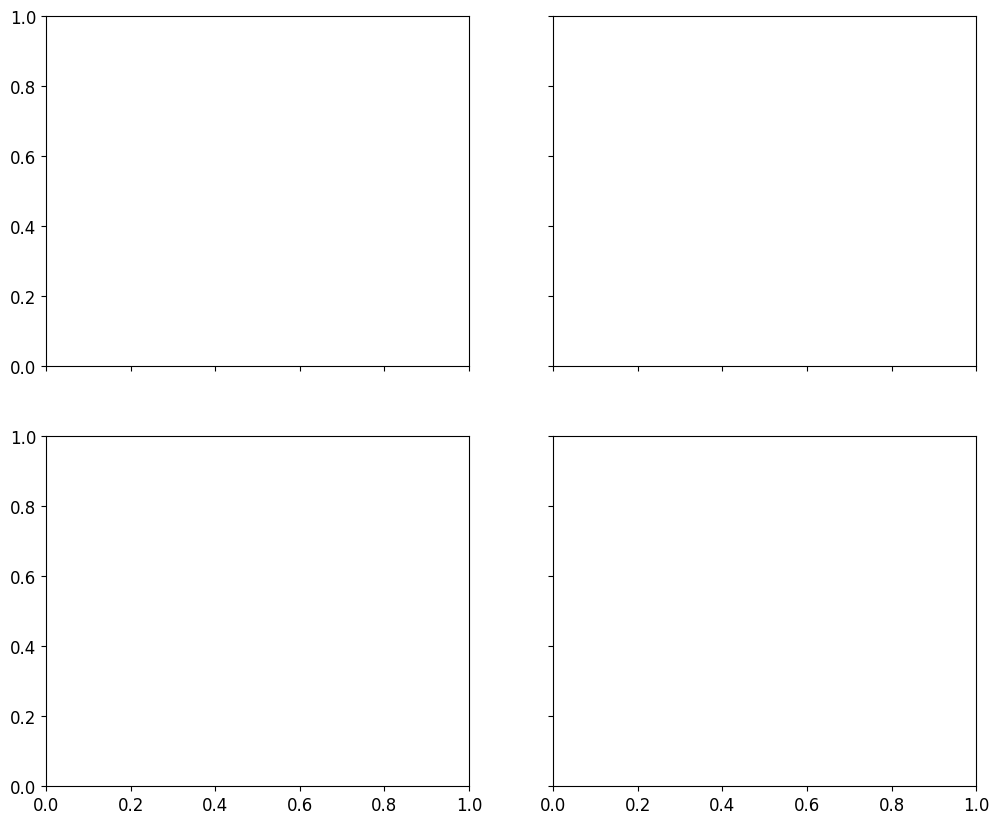

In [18]:
n_neighbors=100
min_dist=0.1
n_components=2
metric='euclidean'
token_colors = {0: 'red', 1: 'green', 2: 'purple'}



fig, ax = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
fit = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, n_components=n_components, metric=metric)
u = fit.fit_transform(reduced_fw_data_fw_model)
for token in [0, 1, 2]:
    mask = reduced_int_fw_data_fw_model[:n] == token
    ax[0, 0].scatter(u[mask, 0], u[mask, 1], s=10, alpha=0.7, c=token_colors[token], label=f'Token {token}')
ax[0, 0].set_title('fw_data_fw_model', fontsize=14)
ax[0, 0].legend()

fit = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, n_components=n_components, metric=metric)
u = fit.fit_transform(reduced_fw_data_bw_model)
for token in [0, 1, 2]:
    mask = reduced_int_fw_data_bw_model[:n] == token
    ax[0, 1].scatter(u[mask, 0], u[mask, 1], s=10, alpha=0.7, c=token_colors[token], label=f'Token {token}')
ax[0, 1].set_title('fw_data_bw_model', fontsize=14)
ax[0, 1].legend()

fit = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, n_components=n_components, metric=metric)
u = fit.fit_transform(reduced_bw_data_fw_model)
for token in [0, 1, 2]:
    mask = reduced_int_bw_data_fw_model[:n] == token
    ax[1, 0].scatter(u[mask, 0], u[mask, 1], s=10, alpha=0.7, c=token_colors[token], label=f'Token {token}')
ax[1, 0].set_title('bw_data_fw_model', fontsize=14)
ax[1, 0].legend()

fit = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, n_components=n_components, metric=metric)
u = fit.fit_transform(reduced_bw_data_bw_model)
for token in [0, 1, 2]:
    mask = reduced_int_bw_data_bw_model[:n] == token
    ax[1, 1].scatter(u[mask, 0], u[mask, 1], s=10, alpha=0.7, c=token_colors[token], label=f'Token {token}' )
ax[1, 1].set_title('bw_data_bw_model', fontsize=14)
ax[1, 1].legend()
plt.tight_layout()
plt.show()

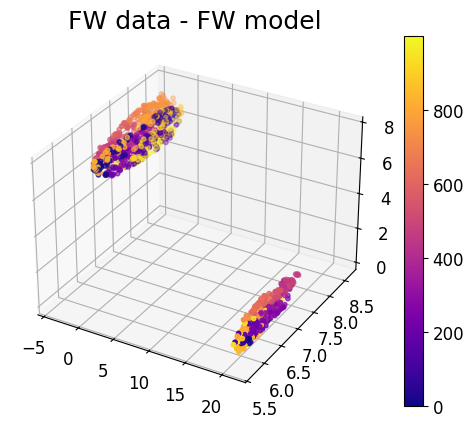

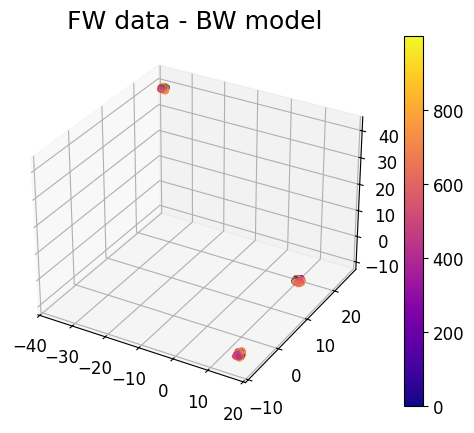

bw_data:


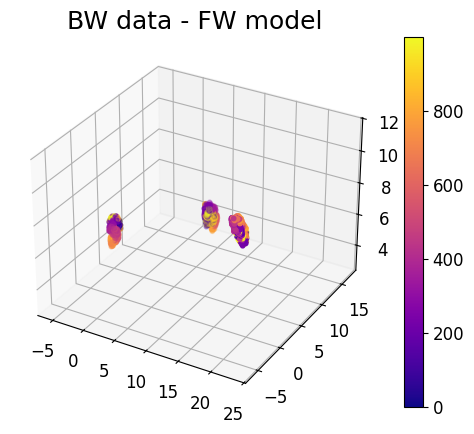

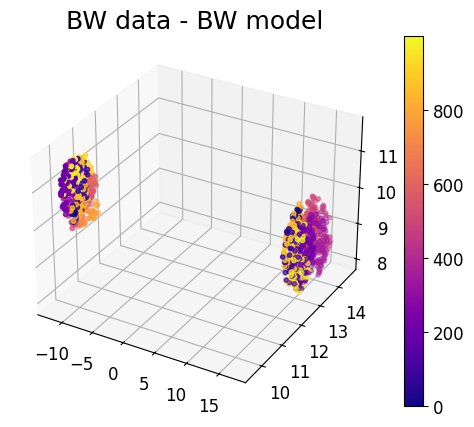

In [35]:
draw_umap(reduced_fw_data_fw_model, n_neighbors=200, n_components=3, color=None, title='FW data - FW model')
draw_umap(reduced_fw_data_bw_model, n_neighbors=200,n_components=3, color=None, title='FW data - BW model')

print("bw_data:")
draw_umap(reduced_bw_data_fw_model, n_neighbors=200,n_components=3, color=None, title='BW data - FW model')
draw_umap(reduced_bw_data_bw_model, n_neighbors=200,n_components=3, color=None, title='BW data - BW model')

loss function

FW/BW LOSS COMPARISON
FW/BW LOSS COMPARISON


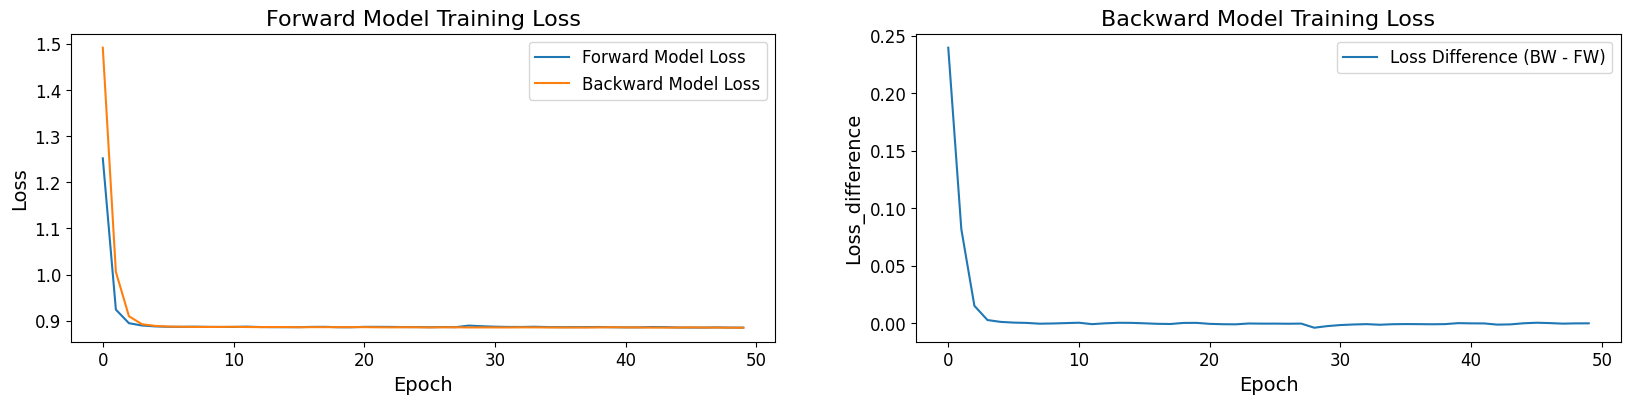

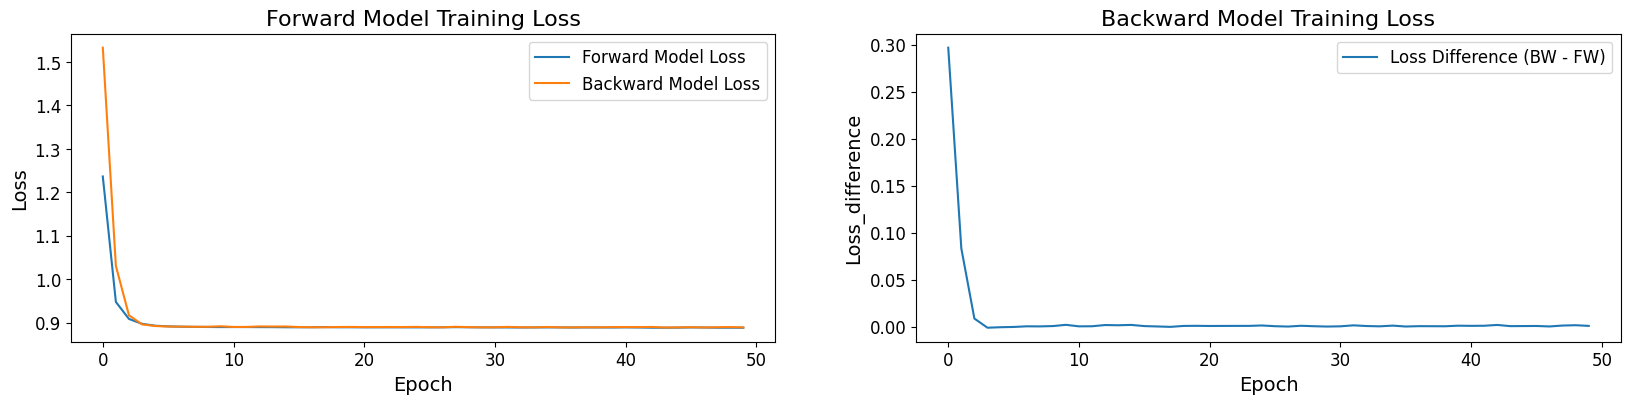

In [36]:
FW_BW_loss_comparison(records_fw_data_fw_model, records_fw_data_rev_model)
FW_BW_loss_comparison(records_rev_data_fw_model, records_rev_data_rev_model)

# General Testing: word embedding vs one hot

In [15]:
max_len = 800
batch_size = 32
max_epochs = 300
num_token = 3
d_model = 20
p, q = 0.4, 0.8

In [9]:

def all_tests(embed_type = "onehot", max_epochs = 100, lr = 1e-2, 
              max_len = 800, batch_size = 32, num_samples = batch_size*10):
    
    rev_train_loader = make_loader(pp = p, qq = q, batch_size = batch_size, seq_len = max_len, 
                               num_samples = num_samples, mode = "backward")
    train_loader = make_loader(pp = p, qq = q, batch_size = batch_size, seq_len = max_len, 
                               num_samples = num_samples, mode = "forward")
    
    print(f"Training models: {embed_type}")
    records_fw_data_fw_model = train_model(train_loader, num_token, d_model, max_len, max_epochs, lr=lr,
                         mode = 'forward', embed_type=embed_type)
    records_rev_data_fw_model = train_model(rev_train_loader, num_token, d_model, max_len, max_epochs, lr=lr,
                         mode = 'forward', embed_type=embed_type)
    records_fw_data_rev_model = train_model(train_loader, num_token, d_model, max_len, max_epochs, lr=lr,
                         mode = 'backward', embed_type=embed_type)
    records_rev_data_rev_model = train_model(rev_train_loader, num_token, d_model, max_len, max_epochs, lr=lr,
                         mode = 'backward', embed_type=embed_type)

    FW_BW_loss_comparison(records_fw_data_fw_model, records_fw_data_rev_model)
    FW_BW_loss_comparison(records_rev_data_fw_model, records_rev_data_rev_model)

    model_fw_data_fw_model = records_fw_data_fw_model.model
    model_bw_data_fw_model = records_rev_data_fw_model.model
    model_fw_data_bw_model = records_fw_data_rev_model.model
    model_bw_data_bw_model = records_rev_data_rev_model.model

    latents_fw_data_fw_model, input_fw_data_fw_model, _ = latent_extraction(model_fw_data_fw_model, train_loader)
    latents_bw_data_fw_model, input_bw_data_fw_model, _ = latent_extraction(model_bw_data_fw_model, rev_train_loader)
    latents_fw_data_bw_model, input_fw_data_bw_model, _ = latent_extraction(model_fw_data_bw_model, train_loader)
    latents_bw_data_bw_model, input_bw_data_bw_model, _ = latent_extraction(model_bw_data_bw_model, rev_train_loader)

    n = 1000

    flat_latents_fw_data_fw_model = latents_fw_data_fw_model.reshape(-1, latents_fw_data_fw_model.shape[-1])
    reduced_fw_data_fw_model = flat_latents_fw_data_fw_model[:n]
    reduced_int_fw_data_fw_model = input_fw_data_fw_model.reshape(-1)[:n]

    flat_latents_bw_data_fw_model = latents_bw_data_fw_model.reshape(-1, latents_bw_data_fw_model.shape[-1])
    reduced_bw_data_fw_model = flat_latents_bw_data_fw_model[:n]
    reduced_int_bw_data_fw_model = input_bw_data_fw_model.reshape(-1)[:n]


    flat_latents_fw_data_bw_model = latents_fw_data_bw_model.reshape(-1, latents_fw_data_bw_model.shape[-1])
    reduced_fw_data_bw_model = flat_latents_fw_data_bw_model[:n]
    reduced_int_fw_data_bw_model = input_fw_data_bw_model.reshape(-1)[:n]

    flat_latents_bw_data_bw_model = latents_bw_data_bw_model.reshape(-1, latents_bw_data_bw_model.shape[-1])
    reduced_bw_data_bw_model = flat_latents_bw_data_bw_model[:n]
    reduced_int_bw_data_bw_model = input_bw_data_bw_model.reshape(-1)[:n]

    n_neighbors=100
    min_dist=0.1
    n_components=2
    metric='euclidean'
    token_colors = {0: 'red', 1: 'green', 2: 'purple'}



    fig, ax = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
    fit = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, n_components=n_components, metric=metric)
    u = fit.fit_transform(reduced_fw_data_fw_model)
    for token in [0, 1, 2]:
        mask = reduced_int_fw_data_fw_model[:n] == token
        ax[0, 0].scatter(u[mask, 0], u[mask, 1], s=10, alpha=0.7, c=token_colors[token], label=f'Token {token}')
    ax[0, 0].set_title('fw_data_fw_model', fontsize=14)
    ax[0, 0].legend()

    fit = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, n_components=n_components, metric=metric)
    u = fit.fit_transform(reduced_fw_data_bw_model)
    for token in [0, 1, 2]:
        mask = reduced_int_fw_data_bw_model[:n] == token
        ax[0, 1].scatter(u[mask, 0], u[mask, 1], s=10, alpha=0.7, c=token_colors[token], label=f'Token {token}')
    ax[0, 1].set_title('fw_data_bw_model', fontsize=14)
    ax[0, 1].legend()

    fit = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, n_components=n_components, metric=metric)
    u = fit.fit_transform(reduced_bw_data_fw_model)
    for token in [0, 1, 2]:
        mask = reduced_int_bw_data_fw_model[:n] == token
        ax[1, 0].scatter(u[mask, 0], u[mask, 1], s=10, alpha=0.7, c=token_colors[token], label=f'Token {token}')
    ax[1, 0].set_title('bw_data_fw_model', fontsize=14)
    ax[1, 0].legend()

    fit = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, n_components=n_components, metric=metric)
    u = fit.fit_transform(reduced_bw_data_bw_model)
    for token in [0, 1, 2]:
        mask = reduced_int_bw_data_bw_model[:n] == token
        ax[1, 1].scatter(u[mask, 0], u[mask, 1], s=10, alpha=0.7, c=token_colors[token], label=f'Token {token}' )
    ax[1, 1].set_title('bw_data_bw_model', fontsize=14)
    ax[1, 1].legend()
    plt.tight_layout()
    plt.show()
    return (reduced_int_fw_data_fw_model, reduced_int_fw_data_bw_model, reduced_int_bw_data_fw_model, reduced_int_bw_data_bw_model), (reduced_int_fw_data_fw_model, reduced_int_fw_data_bw_model, reduced_int_bw_data_fw_model, reduced_int_bw_data_bw_model)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name         | Type               | Params | Mode  | FLOPs
--------------------------------------------------------------------
0 | we           | Embedding          | 60     | train | 0    
1 | pe           | PositionalEncoding | 0      | train | 0    
2 | attn_layers  | ModuleList         | 2.5 K  | train | 0    
3 | ffn_layers   | ModuleList         | 6.6 K  | train | 0    
4 | ln_attn      | ModuleList         | 80     | train | 0    
5 | ln_ffn       | ModuleList         | 80     | train | 0    
6 | output_prj   | Linear             | 63     | train | 0    
  | other params | n/a                | 60     | n/a   | n/a  
--------------------------------------------------------------------
9.5 K     

Training models: onehot
Epoch 299: 100%|██████████| 10/10 [00:00<00:00, 23.29it/s, v_num=1889, train_loss_step=0.871, train_perplexity_step=2.390, train_loss_epoch=0.870, train_perplexity_epoch=2.390]

`Trainer.fit` stopped: `max_epochs=300` reached.


Epoch 299: 100%|██████████| 10/10 [00:00<00:00, 22.17it/s, v_num=1889, train_loss_step=0.871, train_perplexity_step=2.390, train_loss_epoch=0.870, train_perplexity_epoch=2.390]


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name         | Type               | Params | Mode  | FLOPs
--------------------------------------------------------------------
0 | we           | Embedding          | 60     | train | 0    
1 | pe           | PositionalEncoding | 0      | train | 0    
2 | attn_layers  | ModuleList         | 2.5 K  | train | 0    
3 | ffn_layers   | ModuleList         | 6.6 K  | train | 0    
4 | ln_attn      | ModuleList         | 80     | train | 0    
5 | ln_ffn       | ModuleList         | 80     | train | 0    
6 | output_prj   | Linear             | 63     | train | 0    
  | other params | n/a                | 60     | n/a   | n/a  
--------------------------------------------------------------------
9.5 K     

...

Epoch 299: 100%|██████████| 10/10 [00:00<00:00, 22.16it/s, v_num=1891, train_loss_step=0.870, train_perplexity_step=2.390, train_loss_epoch=0.868, train_perplexity_epoch=2.380]


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name         | Type               | Params | Mode  | FLOPs
--------------------------------------------------------------------
0 | we           | Embedding          | 60     | train | 0    
1 | pe           | PositionalEncoding | 0      | train | 0    
2 | attn_layers  | ModuleList         | 2.5 K  | train | 0    
3 | ffn_layers   | ModuleList         | 6.6 K  | train | 0    
4 | ln_attn      | ModuleList         | 80     | train | 0    
5 | ln_ffn       | ModuleList         | 80     | train | 0    
6 | output_prj   | Linear             | 63     | train | 0    
  | other params | n/a                | 60     | n/a   | n/a  
--------------------------------------------------------------------
9.5 K     

Epoch 299: 100%|██████████| 10/10 [00:00<00:00, 23.19it/s, v_num=1892, train_loss_step=0.872, train_perplexity_step=2.390, train_loss_epoch=0.869, train_perplexity_epoch=2.380]

`Trainer.fit` stopped: `max_epochs=300` reached.


Epoch 299: 100%|██████████| 10/10 [00:00<00:00, 22.05it/s, v_num=1892, train_loss_step=0.872, train_perplexity_step=2.390, train_loss_epoch=0.869, train_perplexity_epoch=2.380]
FW/BW LOSS COMPARISON
FW/BW LOSS COMPARISON


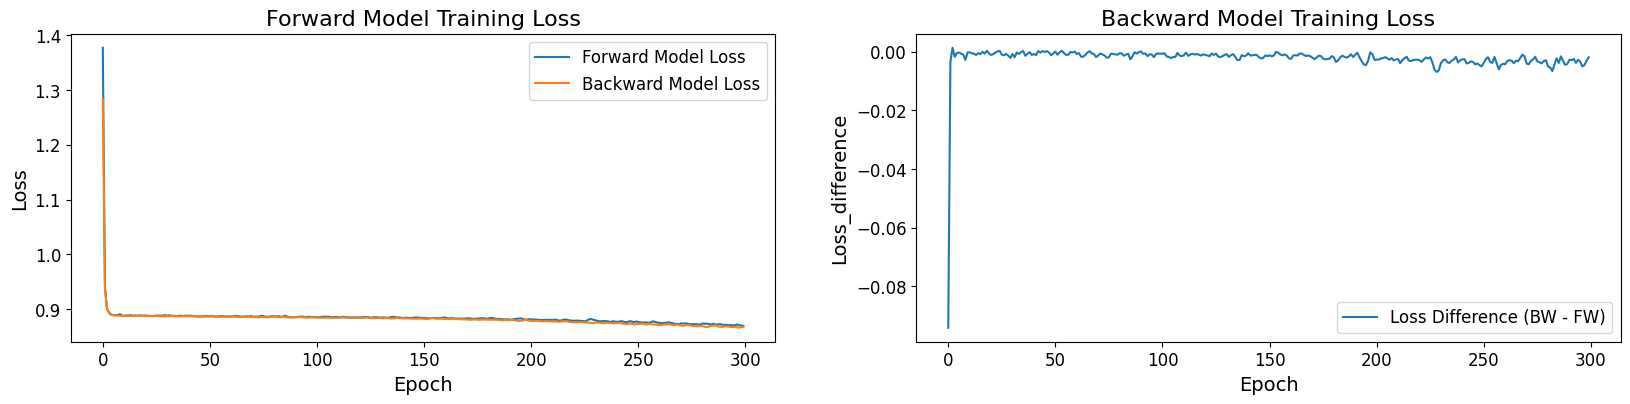

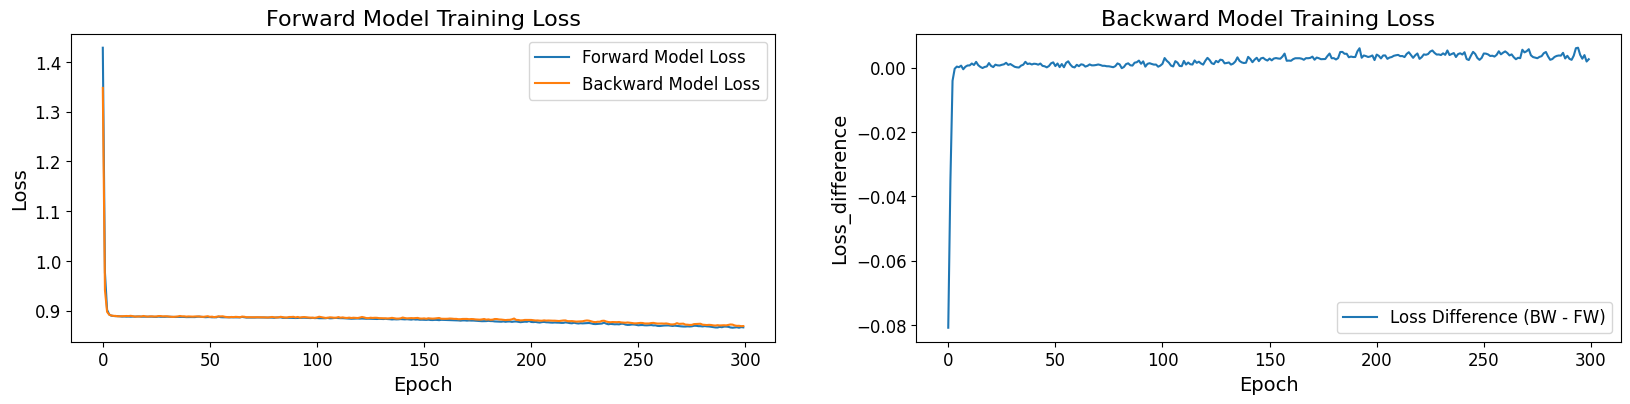

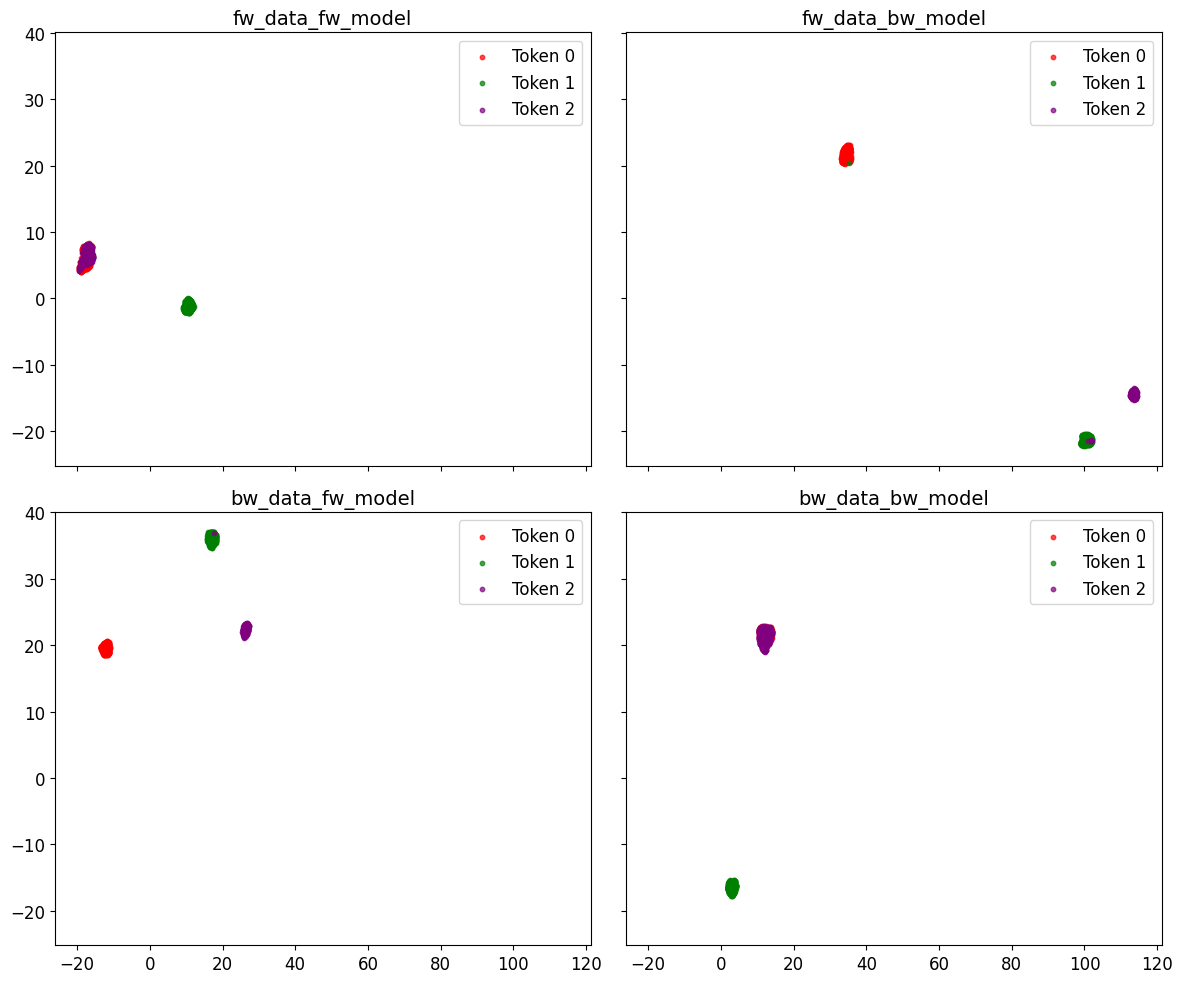

((array([1, 2, 1, 2, 1, 2, 1, 2, 0, 0, 0, 1, 2, 0, 1, 1, 2, 0, 1, 2, 0, 0,
         1, 1, 2, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2, 1, 1, 2, 1, 1, 2, 1, 2,
         0, 1, 1, 2, 0, 0, 0, 1, 2, 0, 0, 0, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
         1, 2, 1, 2, 1, 2, 0, 0, 0, 1, 2, 1, 2, 0, 0, 0, 0, 1, 2, 0, 0, 0,
         1, 2, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1, 2, 1, 2, 0,
         0, 0, 1, 2, 1, 2, 0, 1, 1, 2, 1, 2, 0, 0, 1, 1, 2, 0, 1, 2, 1, 2,
         0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 1, 2, 1, 2, 0, 0, 0, 0, 1, 1,
         2, 1, 2, 1, 1, 2, 1, 2, 1, 2, 0, 1, 2, 1, 1, 2, 0, 1, 2, 1, 2, 1,
         2, 1, 2, 0, 0, 1, 2, 0, 1, 1, 2, 1, 1, 2, 1, 2, 0, 0, 1, 2, 0, 0,
         1, 2, 0, 0, 0, 0, 0, 1, 1, 2, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2,
         0, 0, 0, 0, 0, 1, 2, 1, 2, 1, 2, 0, 0, 0, 0, 1, 2, 0, 0, 1, 2, 0,
         0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 1, 2, 0, 1, 2, 1, 2, 1, 2, 0, 0, 1,
         2, 0, 0, 0, 1, 2, 1, 2, 1, 2, 1, 1, 2, 1, 2, 1, 1, 2, 1, 2, 1, 2,
         0, 1, 2, 0, 0, 0

In [ ]:
max_len = 800
batch_size = 32
max_epochs = 300
all_tests(embed_type = "onehot", max_epochs = max_epochs, max_len = max_len, batch_size = batch_size, num_samples = batch_size*10)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name       | Type               | Params | Mode  | FLOPs
------------------------------------------------------------------
0 | we         | Embedding          | 60     | train | 0    
1 | pe         | PositionalEncoding | 0      | train | 0    
2 | attn       | AttentionModel     | 1.3 K  | train | 0    
3 | output_prj | Linear             | 63     | train | 0    
------------------------------------------------------------------
1.4 K     Trainable params
0         Non-trainable params
1.4 K     Total params
0.006     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode
0         Total Flops


Training models: wordemb


/Users/tisornnaphattalung/Desktop/Quantum/URECA/URECA_qt_llm/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=10` in the `DataLoader` to improve performance.


Epoch 1499: 100%|██████████| 10/10 [00:00<00:00, 45.59it/s, v_num=1901, train_loss_step=0.884, train_perplexity_step=2.420, train_loss_epoch=0.886, train_perplexity_epoch=2.420]

`Trainer.fit` stopped: `max_epochs=1500` reached.


...

Epoch 1499: 100%|██████████| 10/10 [00:00<00:00, 32.16it/s, v_num=1903, train_loss_step=0.885, train_perplexity_step=2.420, train_loss_epoch=0.886, train_perplexity_epoch=2.430]


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name       | Type               | Params | Mode  | FLOPs
------------------------------------------------------------------
0 | we         | Embedding          | 60     | train | 0    
1 | pe         | PositionalEncoding | 0      | train | 0    
2 | attn       | AttentionModel     | 1.3 K  | train | 0    
3 | output_prj | Linear             | 63     | train | 0    
------------------------------------------------------------------
1.4 K     Trainable params
0         Non-trainable params
1.4 K     Total params
0.006     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode
0         Total Flops


Epoch 1499: 100%|██████████| 10/10 [00:00<00:00, 45.40it/s, v_num=1904, train_loss_step=0.883, train_perplexity_step=2.420, train_loss_epoch=0.886, train_perplexity_epoch=2.430]

`Trainer.fit` stopped: `max_epochs=1500` reached.


Epoch 1499: 100%|██████████| 10/10 [00:00<00:00, 43.82it/s, v_num=1904, train_loss_step=0.883, train_perplexity_step=2.420, train_loss_epoch=0.886, train_perplexity_epoch=2.430]
FW/BW LOSS COMPARISON
FW/BW LOSS COMPARISON


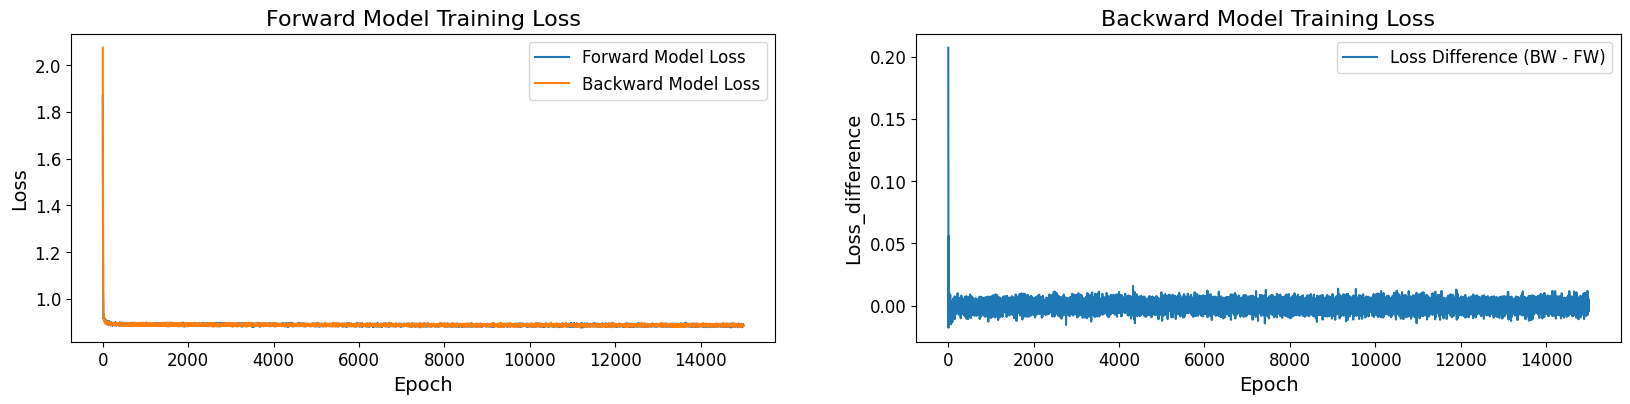

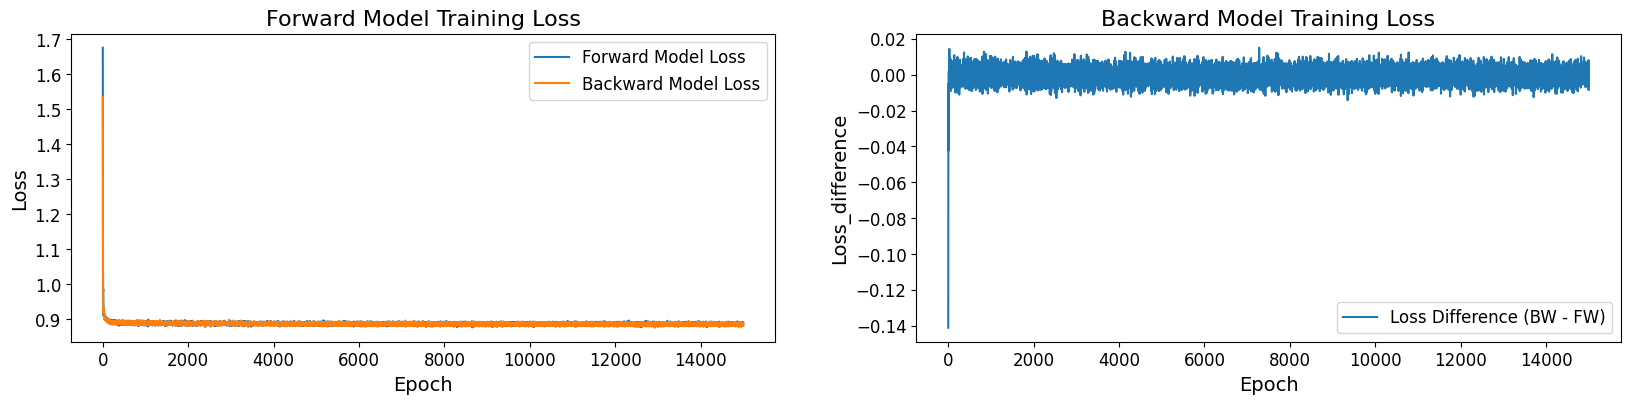

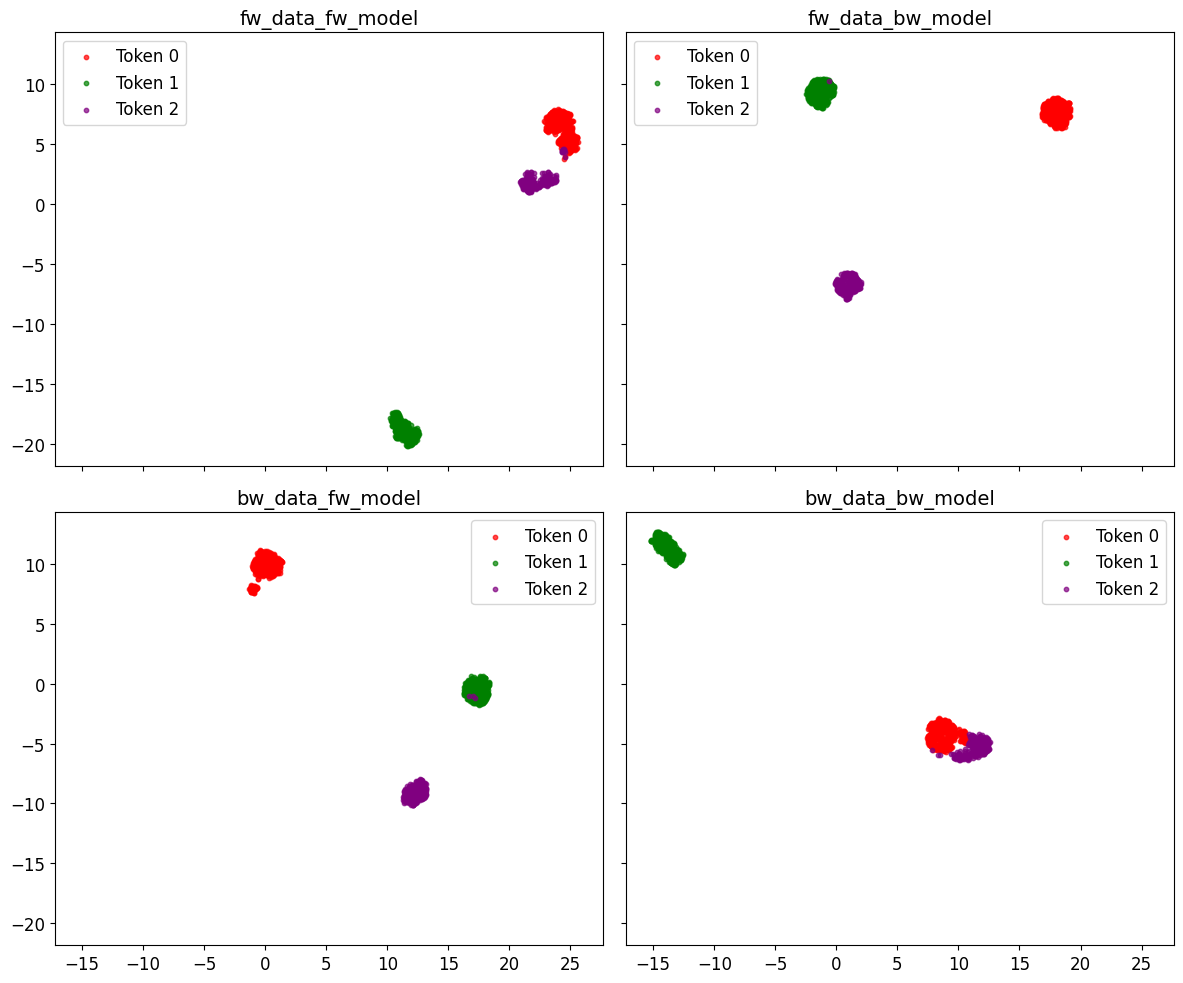

((array([2, 0, 0, 1, 2, 0, 1, 1, 2, 0, 1, 2, 0, 1, 1, 2, 1, 2, 0, 0, 1, 1,
         2, 1, 2, 0, 1, 2, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0,
         0, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 0, 0, 0, 0, 1, 1, 2, 1, 1, 2,
         1, 2, 1, 2, 0, 1, 2, 0, 1, 2, 0, 0, 0, 1, 2, 1, 2, 1, 1, 2, 0, 0,
         0, 0, 1, 2, 0, 1, 2, 1, 2, 1, 1, 2, 1, 2, 1, 2, 0, 1, 1, 1, 1, 2,
         0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 2, 0, 0, 0, 1, 2, 0, 1, 1, 1, 2, 1,
         2, 0, 1, 2, 1, 2, 0, 1, 2, 0, 1, 2, 0, 0, 0, 0, 0, 0, 0, 1, 2, 0,
         0, 1, 2, 1, 1, 2, 1, 1, 2, 0, 1, 2, 1, 2, 1, 2, 0, 1, 2, 0, 0, 0,
         1, 1, 2, 1, 2, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 2, 0, 0,
         0, 0, 0, 0, 1, 1, 2, 0, 1, 2, 0, 0, 0, 0, 0, 0, 1, 2, 1, 2, 0, 1,
         2, 0, 1, 1, 1, 2, 0, 1, 2, 1, 2, 0, 0, 0, 0, 1, 1, 2, 0, 1, 2, 0,
         1, 2, 1, 2, 0, 0, 1, 1, 2, 0, 0, 0, 0, 0, 1, 1, 2, 1, 2, 1, 2, 0,
         1, 2, 1, 2, 1, 2, 0, 1, 2, 1, 1, 2, 0, 1, 2, 1, 2, 1, 2, 1, 2, 1,
         2, 0, 0, 1, 2, 0

In [17]:
max_len = 800
batch_size = 32
max_epochs = 1500
all_tests(embed_type = "wordemb", max_epochs = max_epochs, max_len = max_len, batch_size = batch_size, num_samples = batch_size*10)

In [ ]:
def all_tests_umap3d(reduced_int_tuple, reduced_latent_tuple,
                     n_neighbors=300, min_dist=0.1, metric='euclidean'):
    """
    Plot 4 UMAP 3D subplots with a shared axis scale.

    Parameters
    ----------
    reduced_int_tuple   : (tokens_fw_fw, tokens_fw_bw, tokens_bw_fw, tokens_bw_bw)
                          each is a 1-D int array of token IDs (length n)
    reduced_latent_tuple: (latents_fw_fw, latents_fw_bw, latents_bw_fw, latents_bw_bw)
                          each is a 2-D float array (n, d_model)
    """
    token_colors = {0: 'red', 1: 'green', 2: 'purple'}
    titles = [
        'fw_data_fw_model',
        'fw_data_bw_model',
        'bw_data_fw_model',
        'bw_data_bw_model',
    ]
    positions = [(0, 0), (0, 1), (1, 0), (1, 1)]

    # ── Step 1: fit all 4 UMAPs and collect transformed coordinates ──────────
    embeddings = []
    for latents in reduced_latent_tuple:
        fit = umap.UMAP(
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            n_components=3,
            metric=metric,
        )
        u = fit.fit_transform(latents)   # (n, 3)
        embeddings.append(u)

    # ── Step 2: compute global axis limits across all 4 embeddings ───────────
    all_coords = np.concatenate(embeddings, axis=0)   # (4n, 3)
    global_min = all_coords.min(axis=0)               # (3,)
    global_max = all_coords.max(axis=0)               # (3,)
    pad = (global_max - global_min) * 0.05            # 5 % padding

    xlim = (global_min[0] - pad[0], global_max[0] + pad[0])
    ylim = (global_min[1] - pad[1], global_max[1] + pad[1])
    zlim = (global_min[2] - pad[2], global_max[2] + pad[2])

    # ── Step 3: plot ──────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(14, 11))

    for idx, (u, tokens, title, (row, col)) in enumerate(
        zip(embeddings, reduced_int_tuple, titles, positions)
    ):
        ax = fig.add_subplot(2, 2, idx + 1, projection='3d')

        for token, color in token_colors.items():
            mask = tokens == token
            ax.scatter(
                u[mask, 0], u[mask, 1], u[mask, 2],
                s=8, alpha=0.7, c=color, label=f'Token {token}',
            )

        # enforce shared scale
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.set_zlim(*zlim)

        ax.set_title(title, fontsize=13)
        ax.set_xlabel('UMAP-1', fontsize=9)
        ax.set_ylabel('UMAP-2', fontsize=9)
        ax.set_zlabel('UMAP-3', fontsize=9)
        ax.tick_params(labelsize=7)
        ax.legend(markerscale=1.5, fontsize=8)

    plt.suptitle('UMAP 3D — Latent Space Comparison', fontsize=15, y=1.01)
    plt.tight_layout()
    plt.show()

## TESTING GROUND

/Users/tisornnaphattalung/Desktop/Quantum/URECA/URECA_qt_llm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/Users/tisornnaphattalung/Desktop/Quantum/URECA/URECA_qt_llm/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unle

Training Forward Model...


/Users/tisornnaphattalung/Desktop/Quantum/URECA/URECA_qt_llm/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=10` in the `DataLoader` to improve performance.


Epoch 299: 100%|██████████| 157/157 [00:02<00:00, 61.81it/s, v_num=1689, train_loss_step=0.610, train_loss_epoch=0.616]

`Trainer.fit` stopped: `max_epochs=300` reached.


Epoch 299: 100%|██████████| 157/157 [00:02<00:00, 61.55it/s, v_num=1689, train_loss_step=0.610, train_loss_epoch=0.616]
Plotting forward attention heatmap...
Training Backward Model...


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name       | Type               | Params | Mode  | FLOPs
------------------------------------------------------------------
0 | we         | Embedding          | 60     | train | 0    
1 | pe         | PositionalEncoding | 0      | train | 0    
2 | attn       | AttentionModel     | 1.3 K  | train | 0    
3 | output_prj | Linear             | 63     | train | 0    
4 | loss       | CrossEntropyLoss   | 0      | train | 0    
------------------------------------------------------------------
1.4 K     Trainable params
0         Non-trainable params
1.4 K     Total params
0.006     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode
0         Total Flops


Epoch 299: 100%|██████████| 157/157 [00:02<00:00, 56.45it/s, v_num=1692, train_loss_step=0.607, train_loss_epoch=0.616]

`Trainer.fit` stopped: `max_epochs=300` reached.


Epoch 299: 100%|██████████| 157/157 [00:02<00:00, 56.15it/s, v_num=1692, train_loss_step=0.607, train_loss_epoch=0.616]
Plotting backward attention heatmap...
Analyzing Models...
FW/BW LOSS COMPARISON
Performing PCA on Forward and Backward Latents...
FW/BW LATENTS COMPARISON
STATISTICAL COMPLEXITY COMPARISON

[1/2] Forward Model
----------------------------------------------------------------------
  Empirical (use_t='last'):   0.8888 bits
  Theoretical:               0.9183 bits
  Error:                     0.0295 bits

[2/2] Backward Model
----------------------------------------------------------------------
  Empirical (use_t='first'):  1.3324 bits
  Theoretical:               1.5656 bits
  Error:                     0.2332 bits

SUMMARY

Empirical Complexity:
  Forward (last):   0.8888 bits
  Backward (first): 1.3324 bits
  Difference (FW - BW): -0.4436 bits

Theoretical Complexity:
  Forward:  0.9183 bits
  Backward: 1.5656 bits
  Difference (FW - BW): -0.6473 bits


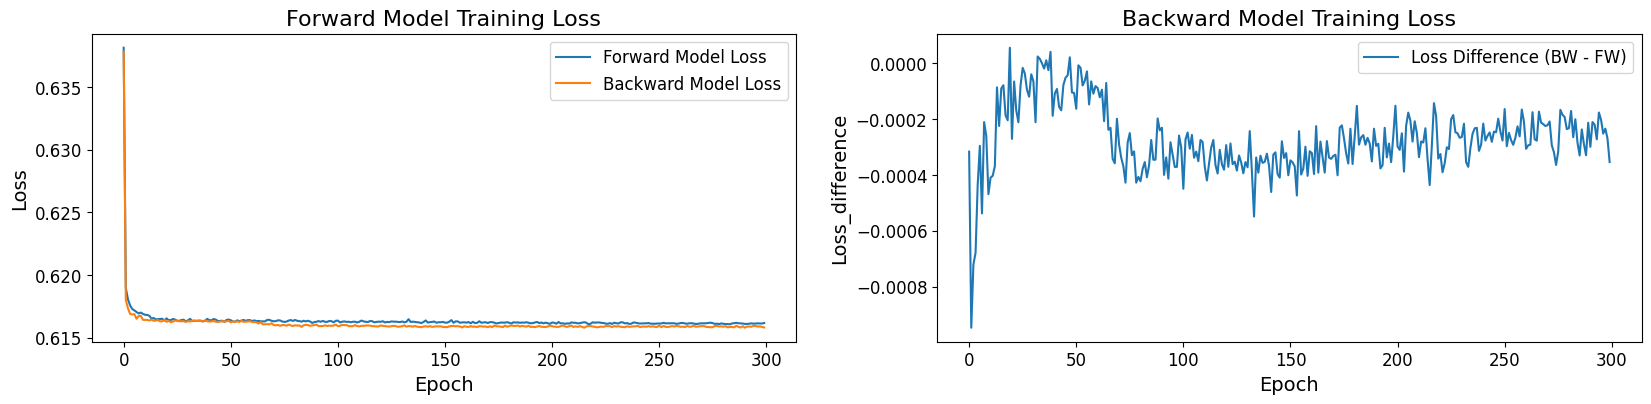

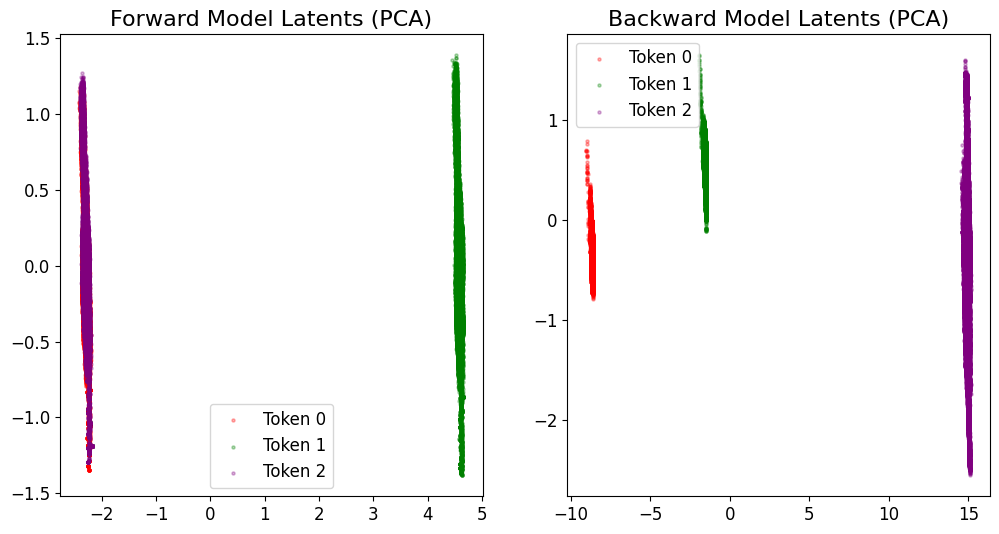

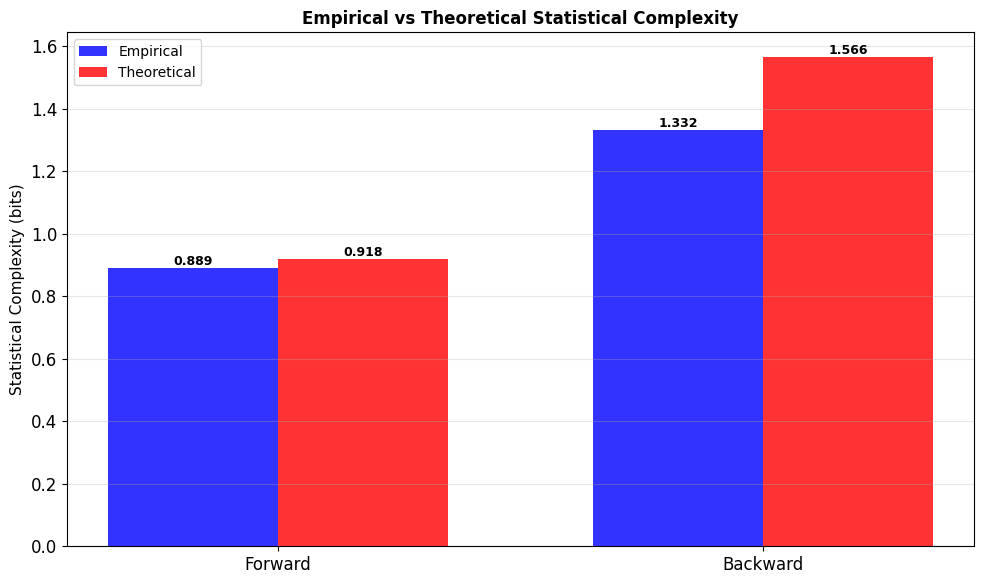

PERPLEXITY COMPARISON
Forward Model Perplexity:  1.8519
Backward Model Perplexity: 176.5403


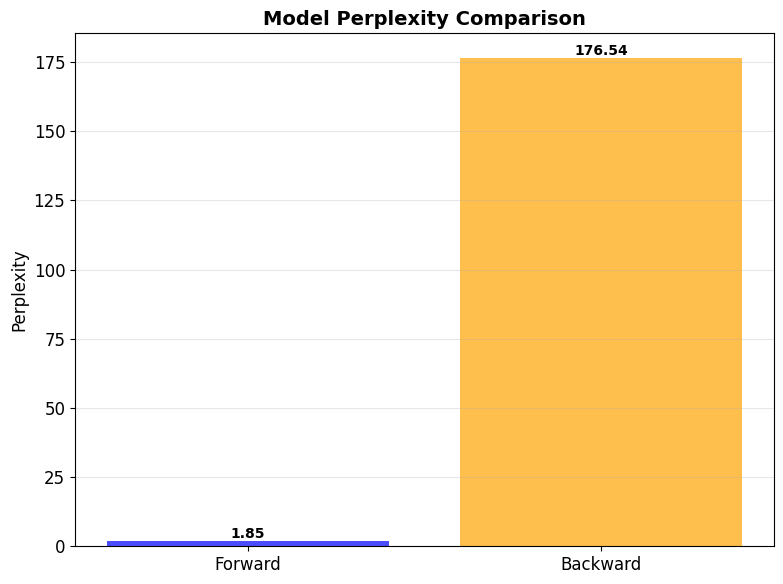


Analysis complete!


In [ ]:



    # Hyperparameters
num_token = 3
d_model = 20
max_len = 500
batch_size = 32
num_samples = 5000
max_epochs = 300
lr = 1e-2
p, q = 0.4, 0.8

    # Data Loader
train_loader = make_loader(pp=p, qq=q, batch_size=batch_size, seq_len=max_len, num_samples=num_samples)

    # Train Forward Model
print("Training Forward Model...")
recorder_fw = train_model(
    train_loader, 
    num_token=num_token, 
    d_model=d_model, 
    max_len=max_len, 
    max_epochs=max_epochs, 
    lr=lr, 
    mode='forward'
)
    
    # Get sample data for visualization (FIX 17: Use actual data, not torch.arange!)
data_iter = iter(train_loader)
sample_inputs, _ = next(data_iter)
sample_seq = sample_inputs[0]  # Get first sequence from batch (contains tokens in [0,1,2])
    
print("Plotting forward attention heatmap...")
    #plot_attention_heatmap(recorder_fw.model, sample_seq)

    # Train Backward Model
print("Training Backward Model...")
recorder_bw = train_model(
    train_loader, 
    num_token=num_token, 
    d_model=d_model, 
    max_len=max_len, 
    max_epochs=max_epochs, 
    lr=lr, 
    mode='backward'
)
    
print("Plotting backward attention heatmap...")
    #plot_attention_heatmap(recorder_bw.model, sample_seq)

    # Model Analysis
print("Analyzing Models...")

    # Loss comparison needs recorders (has .epoch_loss)
FW_BW_loss_comparison(recorder_fw, recorder_bw)

    # Get sample data
data_iter = iter(train_loader)
sample_inputs, _ = next(data_iter)
sample_seq = sample_inputs[0]

    # All these need models (have .eval(), .forward(), etc.)
    #FW_BW_attention_comparison(recorder_fw.model, recorder_bw.model, sample_seq)
compare_FW_BW_latents(recorder_fw.model, recorder_bw.model, data_loader=train_loader, max_batches=10)
statistical_complexity_compare(recorder_fw.model, recorder_bw.model, data_loader=train_loader, p=p, q=q, max_batches=10)
plot_perplexity(recorder_fw.model, recorder_bw.model, data_loader=train_loader, max_batches=10)  # ← Fixed!

print("\nAnalysis complete!")


# UMAP and Latent visualization

In [2]:
from Model_analysis import compare_FW_BW_latents, latent_extraction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

fw_model = recorder_fw.model
bw_model = recorder_bw.model
data_loader = train_loader
max_batches = 10

latents_fw, inputs_fw, _ = latent_extraction(fw_model, data_loader, max_batches)
latents_bw, inputs_bw, _ = latent_extraction(bw_model, data_loader, max_batches)

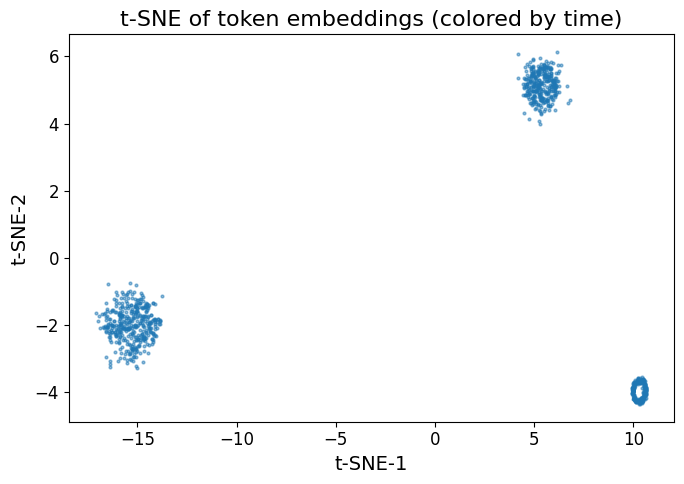

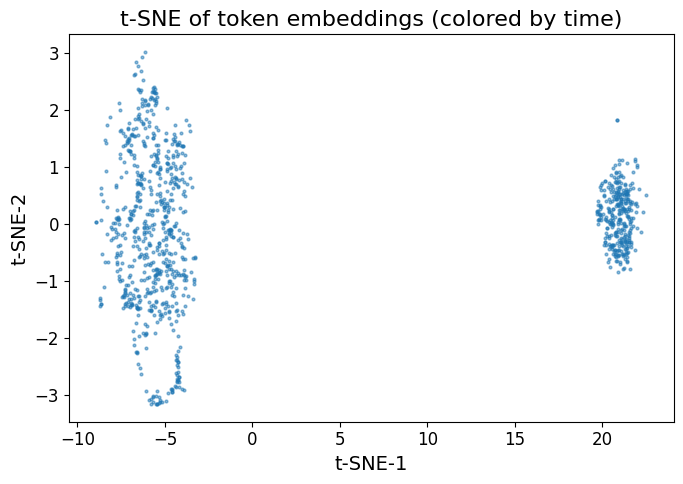

In [3]:

n = 1000

tsne = TSNE(n_components=2, random_state=42, perplexity = 300)
flat_latent = latents_bw.reshape(-1, latents_bw.shape[-1])  # (320*509, 20)
reduced_latents = flat_latent[:n, :] 
X_tsne = tsne.fit_transform(reduced_latents.reshape(-1, reduced_latents.shape[-1]))  # (320*509, 2)
plt.figure(figsize=(7, 5))
plt.plot(X_tsne[:, 0], X_tsne[:, 1], 'o', markersize=2, alpha=0.5)
plt.title("t-SNE of token embeddings (colored by time)")
plt.xlabel("t-SNE-1"); plt.ylabel("t-SNE-2")
plt.tight_layout()

tsne2 = TSNE(n_components=2, random_state=42, perplexity=300)
flat_latent2 = latents_fw.reshape(-1, latents_fw.shape[-1])
reduced_latents2 = flat_latent2[:n, :]
X_tsne2 = tsne2.fit_transform(reduced_latents2.reshape(-1, reduced_latents2.shape[-1]))
plt.figure(figsize=(7, 5))
plt.plot(X_tsne2[:, 0], X_tsne2[:, 1], 'o', markersize=2, alpha=0.5)
plt.title("t-SNE of token embeddings (colored by time)")
plt.xlabel("t-SNE-1"); plt.ylabel("t-SNE-2")
plt.tight_layout()
plt.show()

In [15]:
import umap
def draw_umap(data, color=None, n_neighbors=300, min_dist=0.1, n_components=2, metric='euclidean', title=''):
    fit = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, n_components=n_components, metric=metric)
    u = fit.fit_transform(data)

    fig = plt.figure()
    ax = fig.add_subplot(111) if n_components != 3 else fig.add_subplot(111, projection='3d')

    if color is None:
        color = np.arange(len(data))  # default: timestep coloring

    if n_components == 2:
        sc = ax.scatter(u[:,0], u[:,1], c=color, s=10, cmap='plasma')
        plt.colorbar(sc)
    elif n_components == 3:
        sc = ax.scatter(u[:,0], u[:,1], u[:,2], c=color, s=10, cmap='plasma')
        plt.colorbar(sc)

    plt.title(title, fontsize=18)
    plt.show()


In [7]:
reduced_latents.shape

(1000, 20)

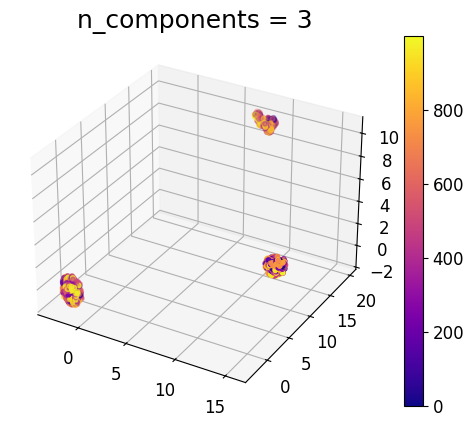

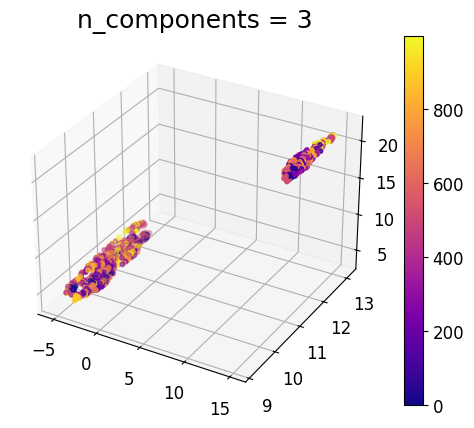

In [17]:
draw_umap(reduced_latents, n_components=3, title='n_components = 3')
draw_umap(reduced_latents2, n_components=3, title='n_components = 3')

# n-m flower model

In [1]:
from Flower_process_generation import flower_process_generation, make_flower_loader

In [4]:
data, states = flower_process_generation(num_samples=1000, seq_len=20, pre_depth=10, n=8, m=2, dice_probs=None)
print(data)

[[6, 8, 6, 9, 0, 9, 1, 8, 4, 8, 3, 9, 4, 8, 1, 9, 1, 8, 2, 9, 0, 9, 3, 9, 6, 8, 5, 9, 5, 9, 1, 8, 2, 8, 6, 8, 5, 8, 3, 8], [4, 8, 5, 8, 2, 9, 5, 8, 5, 8, 6, 8, 0, 9, 3, 9, 6, 8, 3, 9, 2, 9, 2, 9, 6, 9, 4, 8, 6, 9, 6, 8, 4, 8, 7, 9, 0, 9, 1, 9], [7, 9, 7, 9, 6, 8, 4, 8, 2, 9, 1, 9, 7, 9, 2, 9, 5, 8, 7, 8, 6, 8, 3, 8, 7, 9, 3, 8, 1, 8, 7, 9, 6, 8, 0, 9, 3, 9, 7, 9], [2, 9, 1, 8, 0, 9, 0, 9, 1, 8, 3, 9, 2, 9, 0, 9, 7, 9, 0, 9, 6, 8, 4, 8, 7, 9, 4, 8, 4, 8, 2, 8, 5, 8, 7, 9, 2, 8, 5, 8], [5, 8, 3, 9, 4, 9, 7, 9, 3, 9, 5, 9, 3, 9, 0, 9, 4, 9, 4, 8, 0, 8, 1, 8, 1, 8, 4, 8, 6, 8, 2, 8, 4, 8, 3, 9, 1, 9, 3, 9], [1, 9, 2, 9, 4, 8, 7, 9, 3, 8, 1, 9, 4, 8, 7, 9, 4, 8, 7, 9, 2, 9, 0, 9, 5, 8, 6, 8, 0, 9, 6, 8, 7, 9, 6, 8, 5, 8, 0, 9], [2, 9, 5, 8, 7, 9, 4, 8, 5, 8, 2, 8, 1, 9, 5, 8, 4, 9, 5, 8, 2, 9, 4, 8, 5, 9, 4, 8, 7, 9, 7, 8, 2, 9, 4, 8, 6, 9, 4, 9], [7, 9, 1, 8, 3, 9, 2, 8, 4, 9, 0, 9, 7, 9, 6, 8, 5, 8, 2, 9, 1, 9, 7, 9, 4, 8, 7, 9, 2, 8, 2, 8, 3, 9, 3, 8, 5, 9, 4, 8], [0, 8, 2, 9, 6, 8, 1, 8

In [14]:
n=4
m=2
num_token = n + m
d_model = 20
max_len = 500
batch_size = 32
num_samples = batch_size*10
max_epochs = 50
lr = 1e-2
p, q = 0.4, 0.8

train_loader = make_flower_loader(n=n, m=m, dice_probs=None, batch_size=32, seq_len=max_len, 
                       num_samples=num_samples, shuffle=True, mode="forward")
train_loader_bw = make_flower_loader(n=n, m=m, dice_probs=None, batch_size=32, seq_len=max_len, 
                       num_samples=num_samples, shuffle=True, mode = "backward")

records_fw = train_model(train_loader, num_token, d_model, max_len, max_epochs, lr=lr,
                         mode = 'forward', embed_type="onehot")
records_bw = train_model(train_loader_bw, num_token, d_model, max_len, max_epochs, lr=lr,
                         mode = 'forward', embed_type="onehot")

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name         | Type               | Params | Mode  | FLOPs
--------------------------------------------------------------------
0 | we           | Embedding          | 120    | train | 0    
1 | pe           | PositionalEncoding | 0      | train | 0    
2 | attn_layers  | ModuleList         | 2.5 K  | train | 0    
3 | ffn_layers   | ModuleList         | 6.6 K  | train | 0    
4 | ln_attn      | ModuleList         | 80     | train | 0    
5 | ln_ffn       | ModuleList         | 80     | train | 0    
6 | output_prj   | Linear             | 126    | train | 0    
  | other params | n/a                | 120    | n/a   | n/a  
--------------------------------------------------------------------
9.6 K     

Epoch 49: 100%|██████████| 10/10 [00:00<00:00, 16.29it/s, v_num=1917, train_loss_step=1.440, train_perplexity_step=4.200, train_loss_epoch=1.430, train_perplexity_epoch=4.200]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 10/10 [00:00<00:00, 15.72it/s, v_num=1917, train_loss_step=1.440, train_perplexity_step=4.200, train_loss_epoch=1.430, train_perplexity_epoch=4.200]

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores



  | Name         | Type               | Params | Mode  | FLOPs
--------------------------------------------------------------------
0 | we           | Embedding          | 120    | train | 0    
1 | pe           | PositionalEncoding | 0      | train | 0    
2 | attn_layers  | ModuleList         | 2.5 K  | train | 0    
3 | ffn_layers   | ModuleList         | 6.6 K  | train | 0    
4 | ln_attn      | ModuleList         | 80     | train | 0    
5 | ln_ffn       | ModuleList         | 80     | train | 0    
6 | output_prj   | Linear             | 126    | train | 0    
  | other params | n/a                | 120    | n/a   | n/a  
--------------------------------------------------------------------
9.6 K     Trainable params
0         Non-trainable params
9.6 K     Total params
0.039     Total estimated model params size (MB)
27        Modules in train mode
0         Modules in eval mode
0         Total Flops


Epoch 49: 100%|██████████| 10/10 [00:00<00:00, 16.13it/s, v_num=1918, train_loss_step=1.310, train_perplexity_step=3.700, train_loss_epoch=1.300, train_perplexity_epoch=3.680]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 10/10 [00:00<00:00, 15.57it/s, v_num=1918, train_loss_step=1.310, train_perplexity_step=3.700, train_loss_epoch=1.300, train_perplexity_epoch=3.680]


In [15]:
from Model_analysis import compare_FW_BW_latents, latent_extraction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

fw_model = records_fw.model
bw_model = records_bw.model
data_loader = train_loader
max_batches = 10

latents_fw, inputs_fw, _ = latent_extraction(fw_model, data_loader, max_batches)
latents_bw, inputs_bw, _ = latent_extraction(bw_model, data_loader, max_batches)

flat_fw = latents_fw.reshape(-1, latents_fw.shape[-1])
flat_bw = latents_bw.reshape(-1, latents_bw.shape[-1])

n = 3000
reduced_latents_fw = flat_fw[:n]
reduced_latents_bw = flat_bw[:n]

In [16]:
import umap
def draw_umap(data, color=None, n_neighbors=100, min_dist=0.1, n_components=2, metric='euclidean', title=''):
    fit = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, n_components=n_components, metric=metric)
    u = fit.fit_transform(data)

    fig = plt.figure()
    ax = fig.add_subplot(111) if n_components != 3 else fig.add_subplot(111, projection='3d')

    if color is None:
        color = np.arange(len(data))  # default: timestep coloring

    if n_components == 2:
        sc = ax.scatter(u[:,0], u[:,1], c=color, s=10, cmap='plasma')
        plt.colorbar(sc)
    elif n_components == 3:
        sc = ax.scatter(u[:,0], u[:,1], u[:,2], c=color, s=10, cmap='plasma')
        plt.colorbar(sc)

    plt.title(title, fontsize=18)
    plt.show()


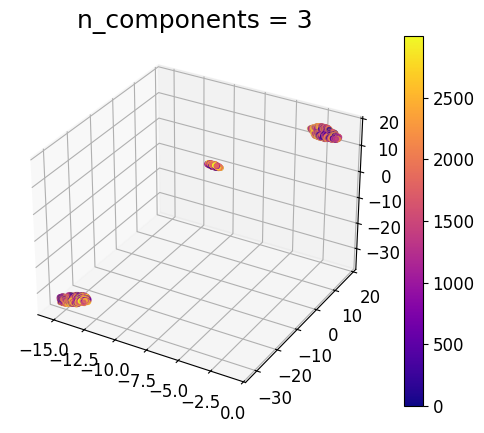

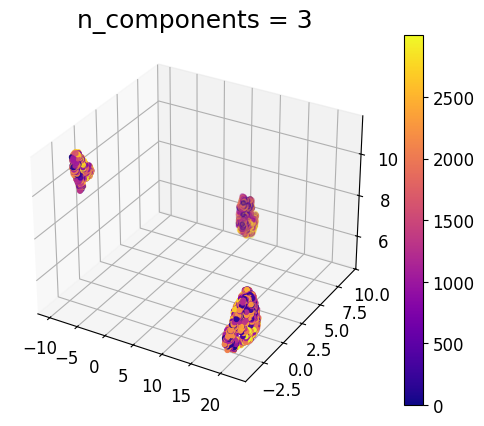

In [21]:
draw_umap(reduced_latents_fw, n_components=3, title='n_components = 3')
draw_umap(reduced_latents_bw, n_components=3, title='n_components = 3')

FW/BW LOSS COMPARISON


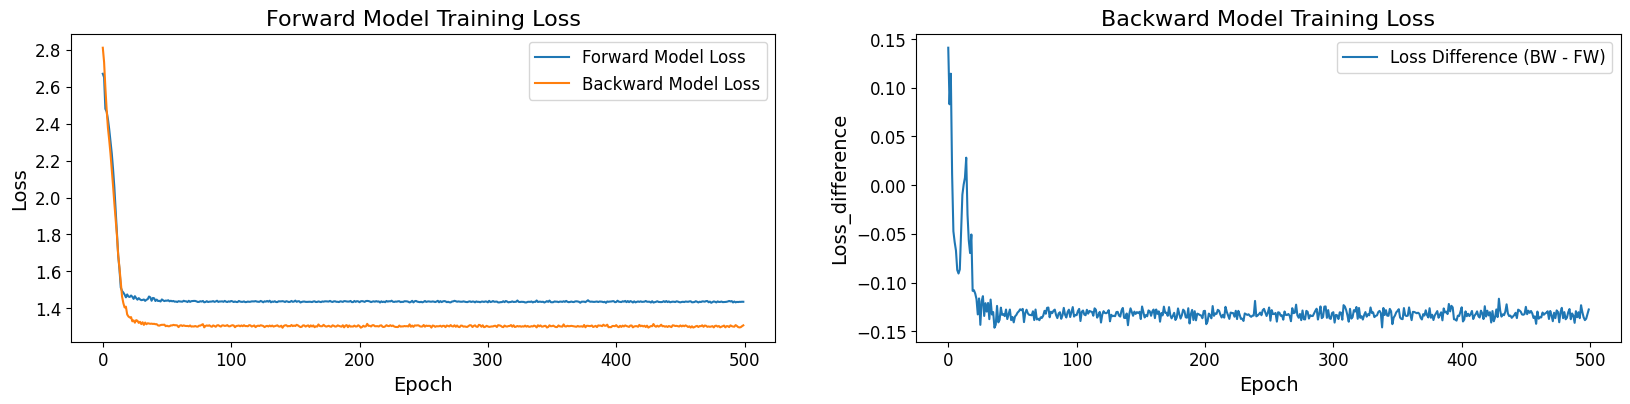

In [23]:
FW_BW_loss_comparison(records_fw, records_bw)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name         | Type               | Params | Mode  | FLOPs
--------------------------------------------------------------------
0 | we           | Embedding          | 240    | train | 0    
1 | pe           | PositionalEncoding | 0      | train | 0    
2 | attn_layers  | ModuleList         | 2.5 K  | train | 0    
3 | ffn_layers   | ModuleList         | 6.6 K  | train | 0    
4 | ln_attn      | ModuleList         | 80     | train | 0    
5 | ln_ffn       | ModuleList         | 80     | train | 0    
6 | output_prj   | Linear             | 252    | train | 0    
  | other params | n/a                | 240    | n/a   | n/a  
--------------------------------------------------------------------
10.0 K    

Epoch 49: 100%|██████████| 10/10 [00:00<00:00, 16.27it/s, v_num=1909, train_loss_step=2.110, train_perplexity_step=8.270, train_loss_epoch=2.110, train_perplexity_epoch=8.260]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 10/10 [00:00<00:00, 15.68it/s, v_num=1909, train_loss_step=2.110, train_perplexity_step=8.270, train_loss_epoch=2.110, train_perplexity_epoch=8.260]

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores



  | Name         | Type               | Params | Mode  | FLOPs
--------------------------------------------------------------------
0 | we           | Embedding          | 240    | train | 0    
1 | pe           | PositionalEncoding | 0      | train | 0    
2 | attn_layers  | ModuleList         | 2.5 K  | train | 0    
3 | ffn_layers   | ModuleList         | 6.6 K  | train | 0    
4 | ln_attn      | ModuleList         | 80     | train | 0    
5 | ln_ffn       | ModuleList         | 80     | train | 0    
6 | output_prj   | Linear             | 252    | train | 0    
  | other params | n/a                | 240    | n/a   | n/a  
--------------------------------------------------------------------
10.0 K    Trainable params
0         Non-trainable params
10.0 K    Total params
0.040     Total estimated model params size (MB)
27        Modules in train mode
0         Modules in eval mode
0         Total Flops


Epoch 49: 100%|██████████| 10/10 [00:00<00:00, 16.11it/s, v_num=1910, train_loss_step=2.200, train_perplexity_step=9.000, train_loss_epoch=2.190, train_perplexity_epoch=8.940]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 10/10 [00:00<00:00, 15.56it/s, v_num=1910, train_loss_step=2.200, train_perplexity_step=9.000, train_loss_epoch=2.190, train_perplexity_epoch=8.940]


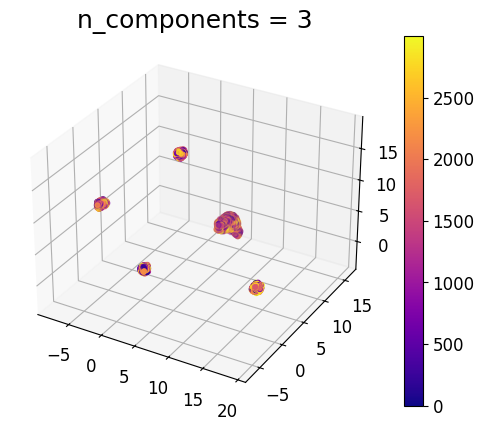

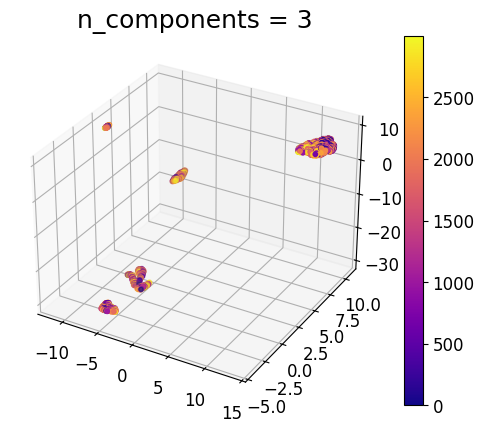

FW/BW LOSS COMPARISON


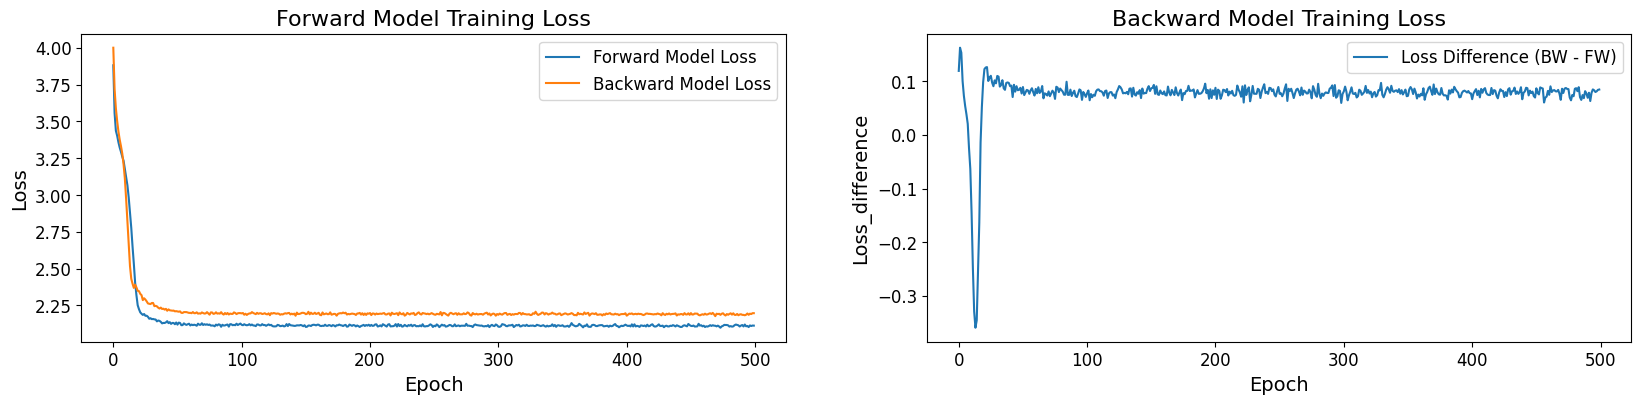

In [46]:
n=4
m=8
num_token = n + m
d_model = 20
max_len = 500
batch_size = 32
num_samples = batch_size*10
max_epochs = 50
lr = 1e-2
p, q = 0.4, 0.8

train_loader = make_flower_loader(n=n, m=m, dice_probs=None, batch_size=32, seq_len=max_len, 
                       num_samples=num_samples, shuffle=True, mode="forward")
train_loader_bw = make_flower_loader(n=n, m=m, dice_probs=None, batch_size=32, seq_len=max_len, 
                       num_samples=num_samples, shuffle=True, mode = "backward")

records_fw = train_model(train_loader, num_token, d_model, max_len, max_epochs, lr=lr,
                         mode = 'forward', embed_type="onehot")
records_bw = train_model(train_loader_bw, num_token, d_model, max_len, max_epochs, lr=lr,
                         mode = 'forward', embed_type="onehot")


fw_model = records_fw.model
bw_model = records_bw.model
data_loader = train_loader
max_batches = 10

latents_fw, inputs_fw, _ = latent_extraction(fw_model, data_loader, max_batches)
latents_bw, inputs_bw, _ = latent_extraction(bw_model, data_loader, max_batches)

flat_fw = latents_fw.reshape(-1, latents_fw.shape[-1])
flat_bw = latents_bw.reshape(-1, latents_bw.shape[-1])

n = 3000
reduced_latents_fw = flat_fw[:n]
reduced_latents_bw = flat_bw[:n]

draw_umap(reduced_latents_fw, n_components=3, title='n_components = 3')
draw_umap(reduced_latents_bw, n_components=3, title='n_components = 3')
FW_BW_loss_comparison(records_fw, records_bw)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name         | Type               | Params | Mode  | FLOPs
--------------------------------------------------------------------
0 | we           | Embedding          | 240    | train | 0    
1 | pe           | PositionalEncoding | 0      | train | 0    
2 | attn_layers  | ModuleList         | 2.5 K  | train | 0    
3 | ffn_layers   | ModuleList         | 6.6 K  | train | 0    
4 | ln_attn      | ModuleList         | 80     | train | 0    
5 | ln_ffn       | ModuleList         | 80     | train | 0    
6 | output_prj   | Linear             | 252    | train | 0    
  | other params | n/a                | 240    | n/a   | n/a  
--------------------------------------------------------------------
10.0 K    

Epoch 49: 100%|██████████| 10/10 [00:00<00:00, 15.65it/s, v_num=1911, train_loss_step=2.280, train_perplexity_step=9.780, train_loss_epoch=2.280, train_perplexity_epoch=9.750]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 10/10 [00:00<00:00, 15.17it/s, v_num=1911, train_loss_step=2.280, train_perplexity_step=9.780, train_loss_epoch=2.280, train_perplexity_epoch=9.750]

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores



  | Name         | Type               | Params | Mode  | FLOPs
--------------------------------------------------------------------
0 | we           | Embedding          | 240    | train | 0    
1 | pe           | PositionalEncoding | 0      | train | 0    
2 | attn_layers  | ModuleList         | 2.5 K  | train | 0    
3 | ffn_layers   | ModuleList         | 6.6 K  | train | 0    
4 | ln_attn      | ModuleList         | 80     | train | 0    
5 | ln_ffn       | ModuleList         | 80     | train | 0    
6 | output_prj   | Linear             | 252    | train | 0    
  | other params | n/a                | 240    | n/a   | n/a  
--------------------------------------------------------------------
10.0 K    Trainable params
0         Non-trainable params
10.0 K    Total params
0.040     Total estimated model params size (MB)
27        Modules in train mode
0         Modules in eval mode
0         Total Flops


Epoch 49: 100%|██████████| 10/10 [00:00<00:00, 15.90it/s, v_num=1912, train_loss_step=2.260, train_perplexity_step=9.560, train_loss_epoch=2.260, train_perplexity_epoch=9.590]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 10/10 [00:00<00:00, 15.37it/s, v_num=1912, train_loss_step=2.260, train_perplexity_step=9.560, train_loss_epoch=2.260, train_perplexity_epoch=9.590]


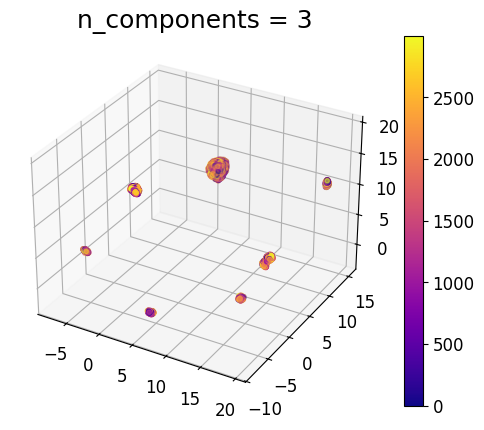

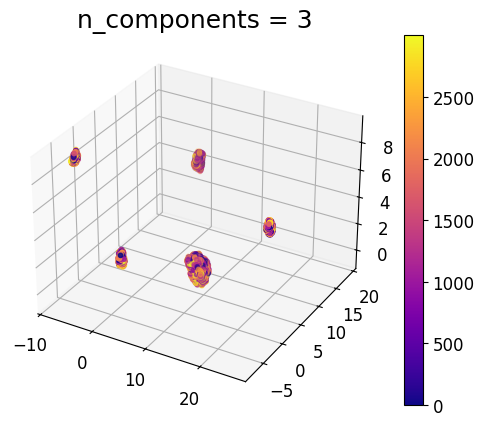

FW/BW LOSS COMPARISON


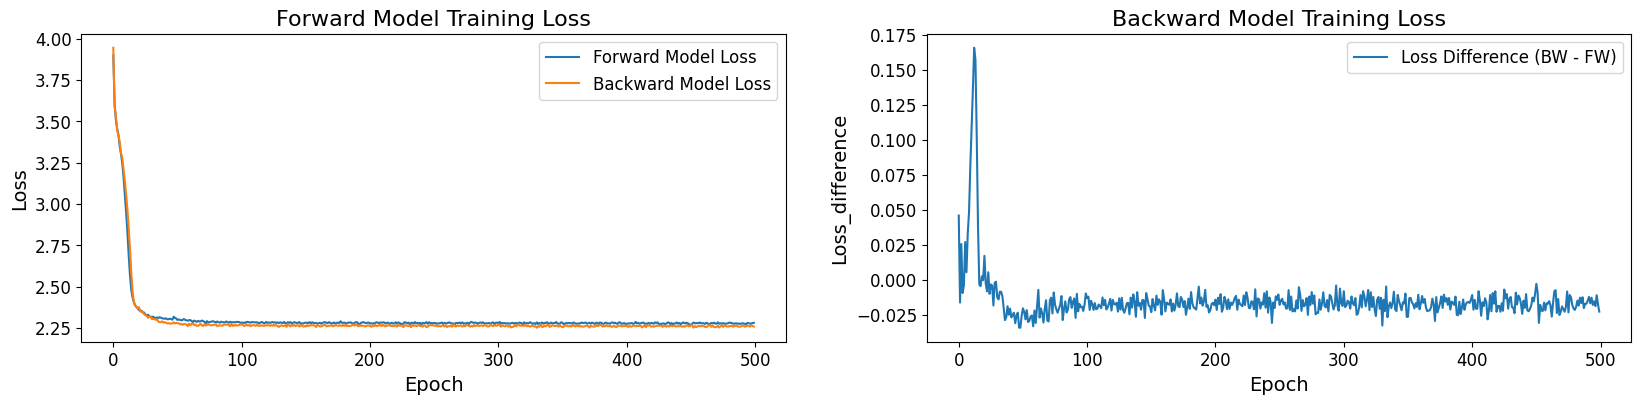

In [47]:
n=8
m=4
num_token = n + m
d_model = 20
max_len = 500
batch_size = 32
num_samples = batch_size*10
max_epochs = 50
lr = 1e-2
p, q = 0.4, 0.8

train_loader = make_flower_loader(n=n, m=m, dice_probs=None, batch_size=32, seq_len=max_len, 
                       num_samples=num_samples, shuffle=True, mode="forward")
train_loader_bw = make_flower_loader(n=n, m=m, dice_probs=None, batch_size=32, seq_len=max_len, 
                       num_samples=num_samples, shuffle=True, mode = "backward")

records_fw = train_model(train_loader, num_token, d_model, max_len, max_epochs, lr=lr,
                         mode = 'forward', embed_type="onehot")
records_bw = train_model(train_loader_bw, num_token, d_model, max_len, max_epochs, lr=lr,
                         mode = 'forward', embed_type="onehot")


fw_model = records_fw.model
bw_model = records_bw.model
data_loader = train_loader
max_batches = 10

latents_fw, inputs_fw, _ = latent_extraction(fw_model, data_loader, max_batches)
latents_bw, inputs_bw, _ = latent_extraction(bw_model, data_loader, max_batches)

flat_fw = latents_fw.reshape(-1, latents_fw.shape[-1])
flat_bw = latents_bw.reshape(-1, latents_bw.shape[-1])

n = 3000
reduced_latents_fw = flat_fw[:n]
reduced_latents_bw = flat_bw[:n]

draw_umap(reduced_latents_fw, n_components=3, title='n_components = 3')
draw_umap(reduced_latents_bw, n_components=3, title='n_components = 3')
FW_BW_loss_comparison(records_fw, records_bw)